In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as pt
import seaborn as sb
import sklearn as sl 
import scipy as sp
import os
from scipy.interpolate import CubicSpline
from scipy.stats import skew, kurtosis, entropy
from scipy.stats import gaussian_kde
from scipy.integrate import simpson
import statsmodels.api as sm
import scipy.stats as st
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
import bt

In [2]:
ticker = "^SPX"
data = yf.download(ticker, start='2020-01-01', end='2025-08-23')
data.rename(columns={"Adj Close": "Price"}, inplace=True)

/var/folders/s4/vtqjzhms05v71zjcpqxkq1dm0000gn/T/ipykernel_99497/4212347020.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2020-01-01', end='2025-08-23')
[*********************100%***********************]  1 of 1 completed


In [3]:
data.head(-5)

Price,Close,High,Low,Open,Volume
Ticker,^SPX,^SPX,^SPX,^SPX,^SPX
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000
...,...,...,...,...,...
2025-08-11,6373.450195,6407.250000,6364.060059,6389.669922,4652400000
2025-08-12,6445.759766,6446.549805,6385.759766,6395.169922,5135300000


In [4]:
data.to_csv("SPX.csv")

In [5]:
tick = yf.Ticker("^SPX")

# Get available option expiration dates
expirations = tick.options
print(expirations)

('2025-09-02', '2025-09-03', '2025-09-04', '2025-09-05', '2025-09-08', '2025-09-09', '2025-09-10', '2025-09-11', '2025-09-12', '2025-09-15', '2025-09-16', '2025-09-17', '2025-09-18', '2025-09-19', '2025-09-22', '2025-09-23', '2025-09-24', '2025-09-25', '2025-09-26', '2025-09-29', '2025-09-30', '2025-10-03', '2025-10-06', '2025-10-10', '2025-10-17', '2025-10-31', '2025-11-21', '2025-11-28', '2025-12-19', '2025-12-31', '2026-01-16', '2026-01-30', '2026-02-20', '2026-03-20', '2026-03-31', '2026-04-17', '2026-05-15', '2026-06-18', '2026-06-30', '2026-07-17', '2026-08-21', '2026-09-18', '2026-12-18', '2027-06-17', '2027-12-17', '2028-12-15', '2029-12-21', '2030-12-20')


In [6]:
# Choose an expiration date (e.g., the first one)
for i in range(3, 25):
    selected_date = expirations[i]

    # Fetch the option chain for that date
    option_chain = tick.option_chain(selected_date)
    calls = option_chain.calls
    puts = option_chain.puts

    # Save as CSV
    calls.to_csv("SPX_calls_" + selected_date + ".csv", index=False)
    puts.to_csv("SPX_puts_" + selected_date + ".csv", index=False)

print("Saved SPY option chain to your computer.")

Saved SPY option chain to your computer.


In [7]:
def find_files(base_directory):
    calls_file_paths = []
    calls_date = []
    puts_file_paths = []
    puts_date = []

    # Walk through the base directory SPX_calls_2027-01-15.csv
    for root, dirs, files in os.walk(base_directory):
        for file in files:
            if file.endswith('.csv'):
                # Full file path
                file_path = os.path.join(root, file)

                if "SPX_calls_" in file:
                    calls_file_paths.append(file_path)
                    # Split the file name to isolate the numeric value after "H"
                    parts = file.split("SPX_calls_")
                    part = parts[1].split(".")
                    try:
                        # Extract and convert the numeric value to float
                        calls_date.append(part[0])
                    except ValueError:
                        print(f"Could not extract D value from file: {file}")
                        calls_date.append(None)

                if "SPX_puts_" in file:
                    puts_file_paths.append(file_path)
                    # Split the file name to isolate the numeric value after "H"
                    parts = file.split("SPX_puts_")
                    part = parts[1].split(".")
                    try:
                        # Extract and convert the numeric value to float
                        puts_date.append(part[0])
                    except ValueError:
                        print(f"Could not extract D value from file: {file}")
                        puts_date.append(None)

                else:
                    # If not continue
                    continue

    return calls_file_paths, calls_date, puts_file_paths, puts_date


base_directory = r"/Users/dhaneshg/Downloads/Dhanesh/data/option_chain"

calls_filepaths, calls_dates, puts_filepaths, puts_dates = find_files(base_directory)

In [8]:
Dates = []

call_mean_rn = []
put_mean_rn = []

call_var_rn = []
put_var_rn = []

call_std_rn = []
put_std_rn = []

call_skew_rn = []
put_skew_rn = []

call_kurt_rn = []
put_kurt_rn = []

call_entropy_rn = []
put_entropy_rn = []

###

call_p_below_1sigma_rn = []
call_p_above_1sigma_rn = []

put_p_below_1sigma_rn = []
put_p_above_1sigma_rn = []

call_p_below_2sigma_rn = []
call_p_above_2sigma_rn = []

put_p_below_2sigma_rn = []
put_p_above_2sigma_rn = []

Call Expiry Date: 2025-09-29 # Put Expiry Date: 2025-09-29
Call Mean: 6521.6540
Call Std Dev: 197.9408
Call Skewness: -0.1207
Call Kurtosis: 3.2343
Call Entropy: 2.9089
Call P(Below -1σ): 0.0982
Call P(Above +1σ): 0.1342
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0145
Put Mean: 6417.4592
Put Std Dev: 239.5807
Put Skewness: -2.8920
Put Kurtosis: 16.4242
Put Entropy: 2.9518
Put P(Below -1σ): 0.1198
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0421
Put P(Above +2σ): 0.0000


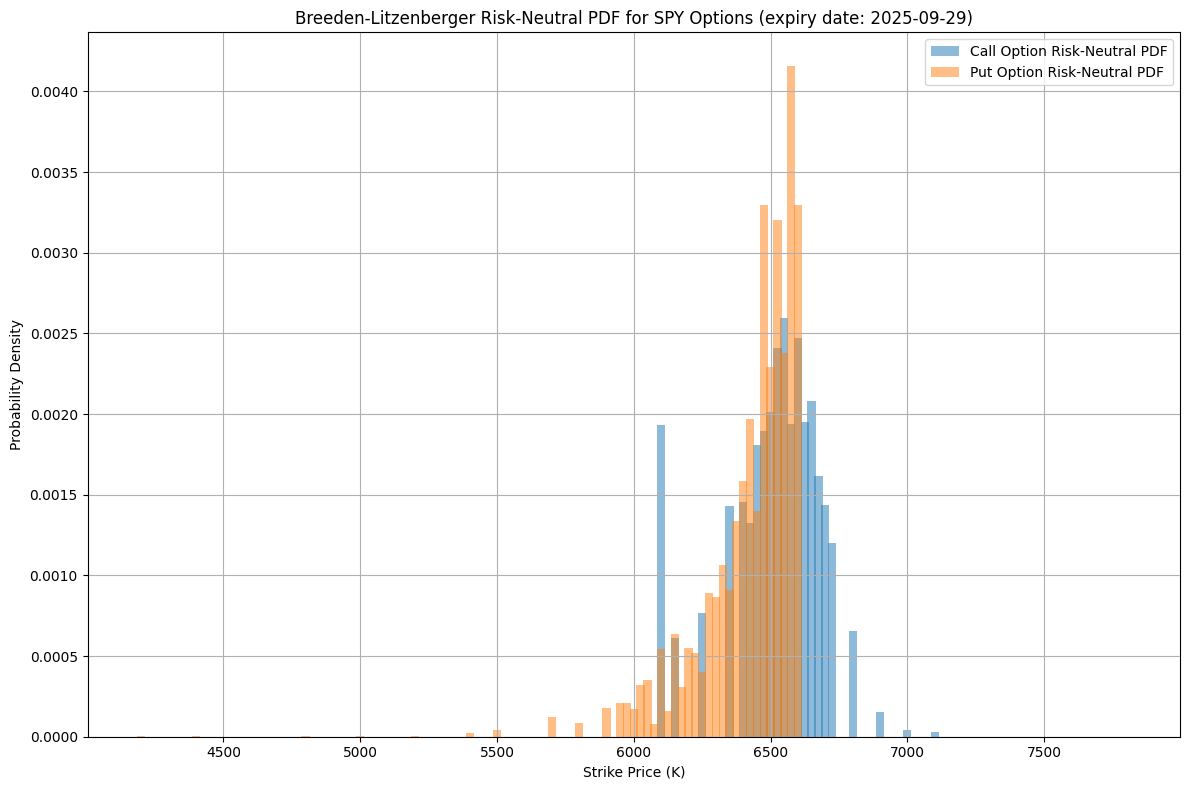

Call Expiry Date: 2025-09-15 # Put Expiry Date: 2025-09-15
Call Mean: 5600.9670
Call Std Dev: 144.8421
Call Skewness: 4.8947
Call Kurtosis: 30.4572
Call Entropy: 1.9997
Call P(Below -1σ): 0.0000
Call P(Above +1σ): 0.0638
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0246
Put Mean: 6463.7413
Put Std Dev: 235.0083
Put Skewness: -4.4516
Put Kurtosis: 43.2142
Put Entropy: 3.1946
Put P(Below -1σ): 0.0806
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0283
Put P(Above +2σ): 0.0000


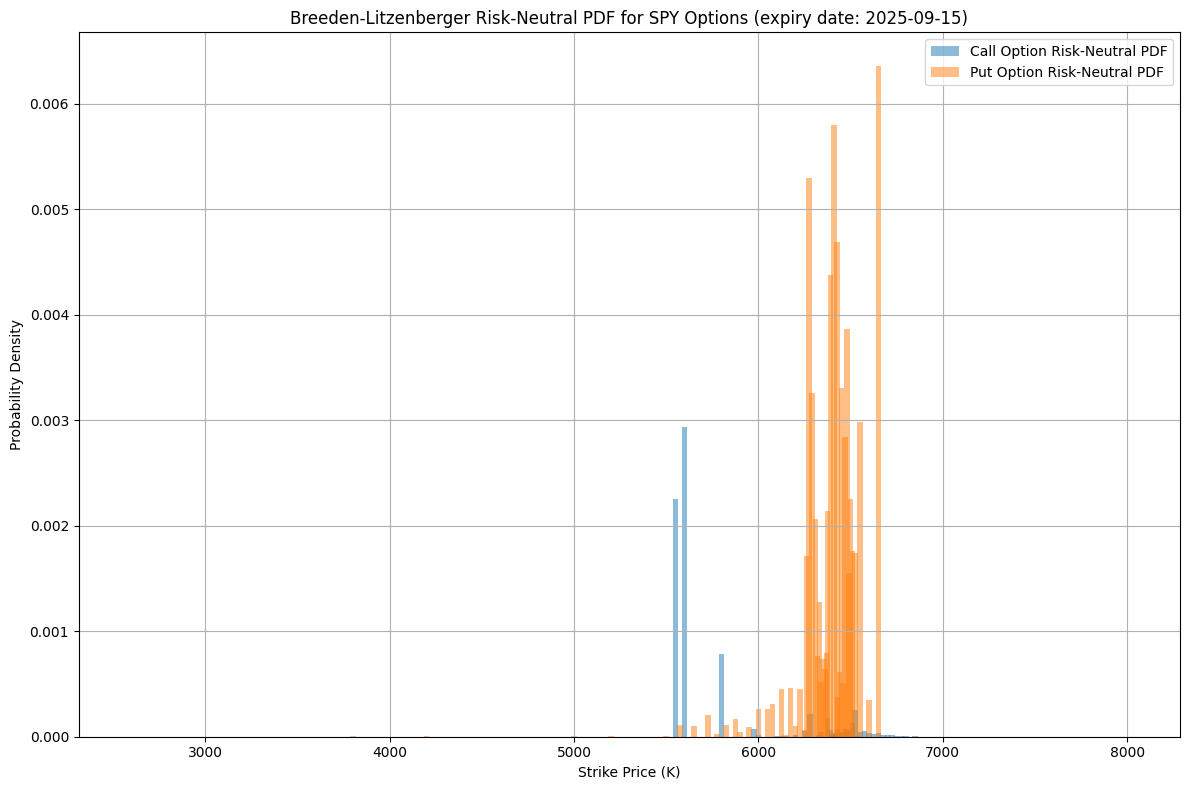

Call Expiry Date: 2025-09-16 # Put Expiry Date: 2025-09-16
Call Mean: 6441.8514
Call Std Dev: 143.8571
Call Skewness: 0.6618
Call Kurtosis: 2.6101
Call Entropy: 2.9098
Call P(Below -1σ): 0.1460
Call P(Above +1σ): 0.1679
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0226
Put Mean: 6506.6880
Put Std Dev: 155.8830
Put Skewness: -5.0142
Put Kurtosis: 61.8694
Put Entropy: 2.6837
Put P(Below -1σ): 0.1067
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0360
Put P(Above +2σ): 0.0000


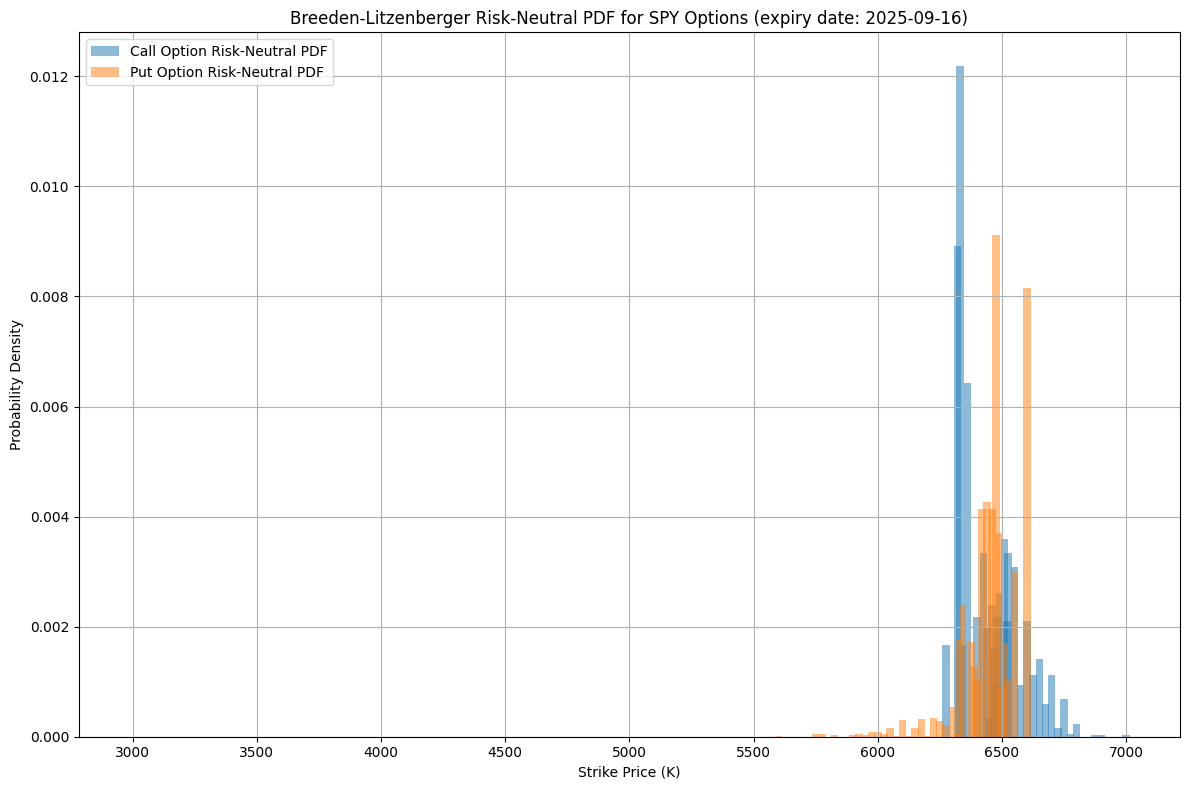

Call Expiry Date: 2025-09-02 # Put Expiry Date: 2025-09-02
Call Mean: 6070.8674
Call Std Dev: 86.4177
Call Skewness: 2.8554
Call Kurtosis: 22.2234
Call Entropy: 1.6522
Call P(Below -1σ): 0.0068
Call P(Above +1σ): 0.0613
Call P(Below -2σ): 0.0052
Call P(Above +2σ): 0.0582
Put Mean: 6667.3454
Put Std Dev: 117.9561
Put Skewness: -3.2960
Put Kurtosis: 22.4989
Put Entropy: 3.0891
Put P(Below -1σ): 0.1139
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0800
Put P(Above +2σ): 0.0000


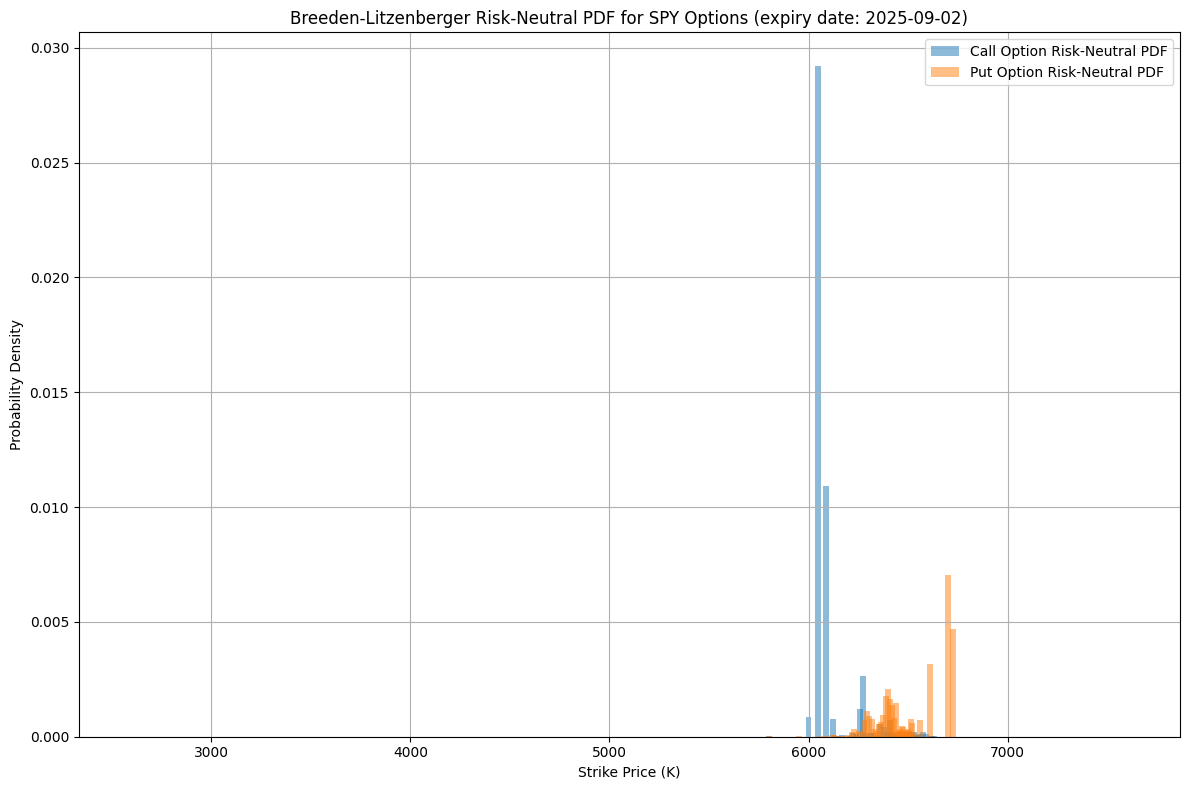

Call Expiry Date: 2025-09-03 # Put Expiry Date: 2025-09-03
Call Mean: 4843.3476
Call Std Dev: 1086.9505
Call Skewness: -1.0935
Call Kurtosis: 2.8614
Call Entropy: 2.5616
Call P(Below -1σ): 0.0000
Call P(Above +1σ): 0.0969
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0000
Put Mean: 6743.3234
Put Std Dev: 270.3666
Put Skewness: -1.1298
Put Kurtosis: 5.1780
Put Entropy: 3.4404
Put P(Below -1σ): 0.1902
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0174
Put P(Above +2σ): 0.0000


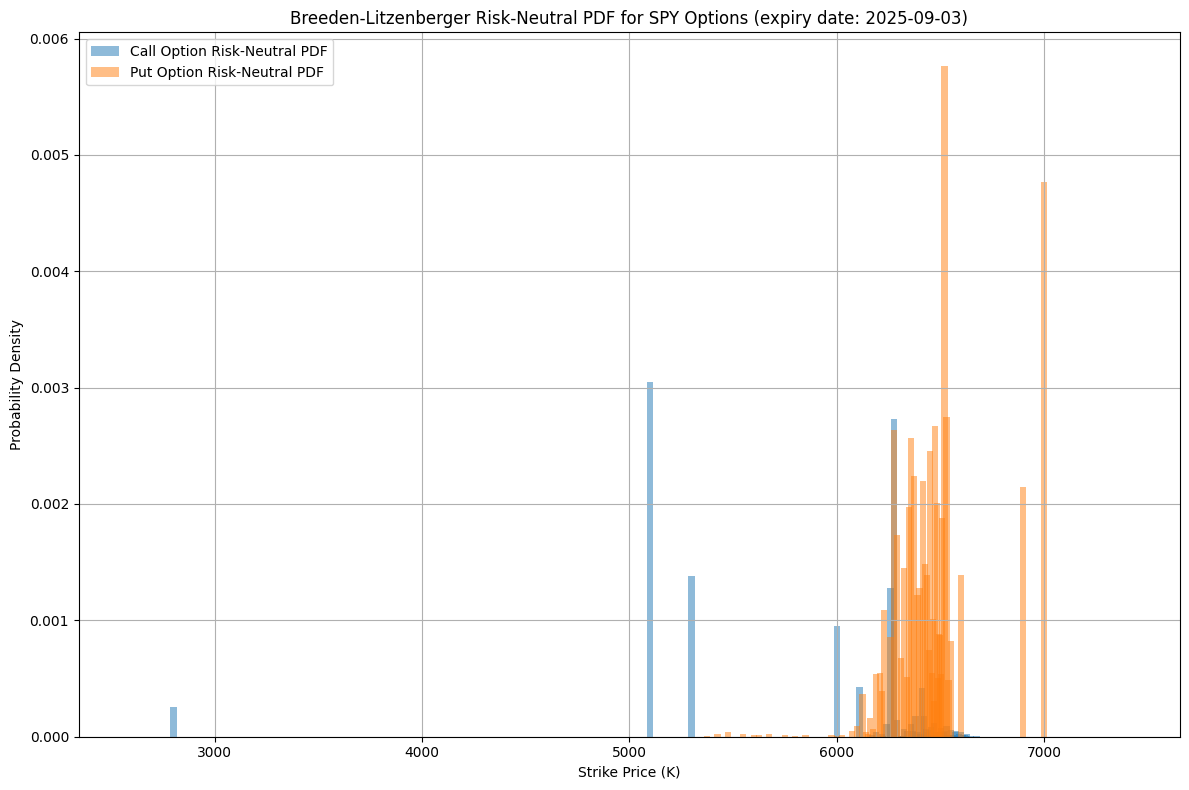

Call Expiry Date: 2025-09-17 # Put Expiry Date: 2025-09-17
Call Mean: 6512.0016
Call Std Dev: 137.5772
Call Skewness: 0.0211
Call Kurtosis: 2.5549
Call Entropy: 3.0222
Call P(Below -1σ): 0.1544
Call P(Above +1σ): 0.1601
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0171
Put Mean: 6395.5458
Put Std Dev: 213.3258
Put Skewness: -3.8307
Put Kurtosis: 31.4975
Put Entropy: 3.1139
Put P(Below -1σ): 0.1139
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0375
Put P(Above +2σ): 0.0000


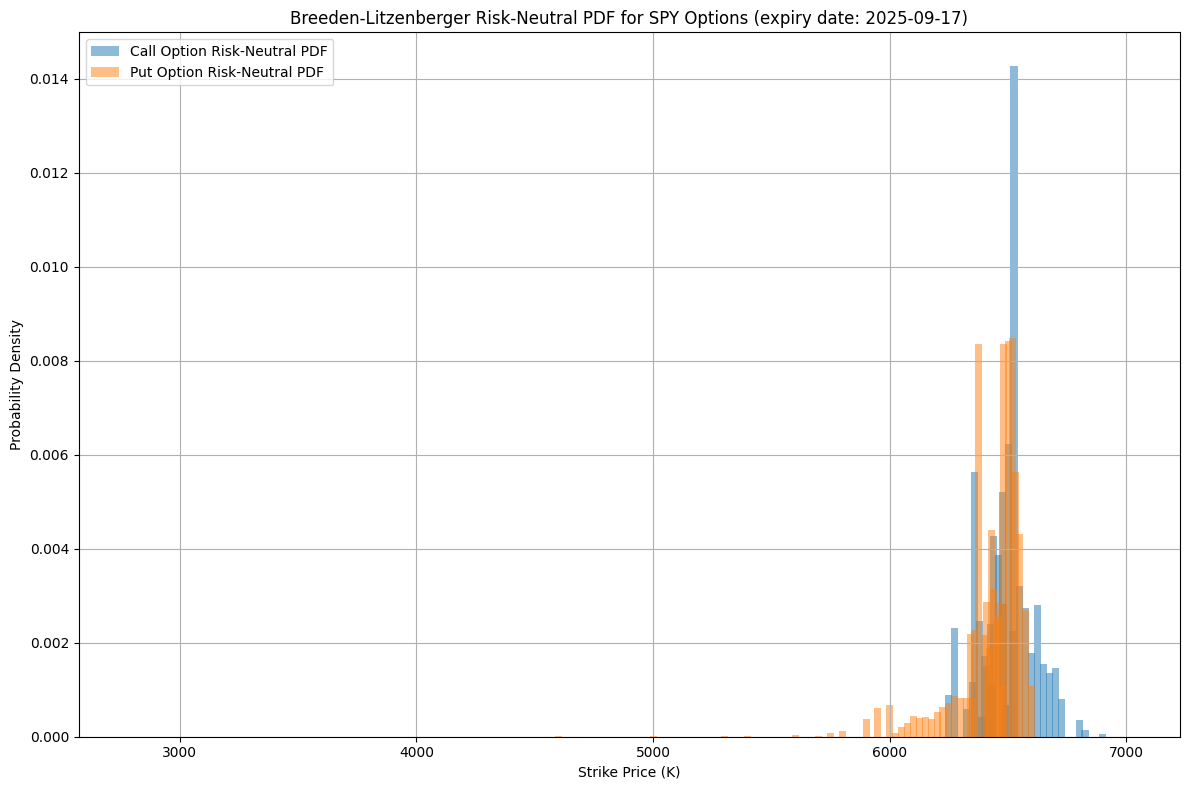

Call Expiry Date: 2025-09-12 # Put Expiry Date: 2025-09-12
Call Mean: 5890.3093
Call Std Dev: 370.2525
Call Skewness: 0.6006
Call Kurtosis: 1.6465
Call Entropy: 3.3674
Call P(Below -1σ): 0.0090
Call P(Above +1σ): 0.2971
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0155
Put Mean: 6649.6224
Put Std Dev: 234.3510
Put Skewness: -1.8013
Put Kurtosis: 8.3421
Put Entropy: 3.5700
Put P(Below -1σ): 0.2103
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0427
Put P(Above +2σ): 0.0000


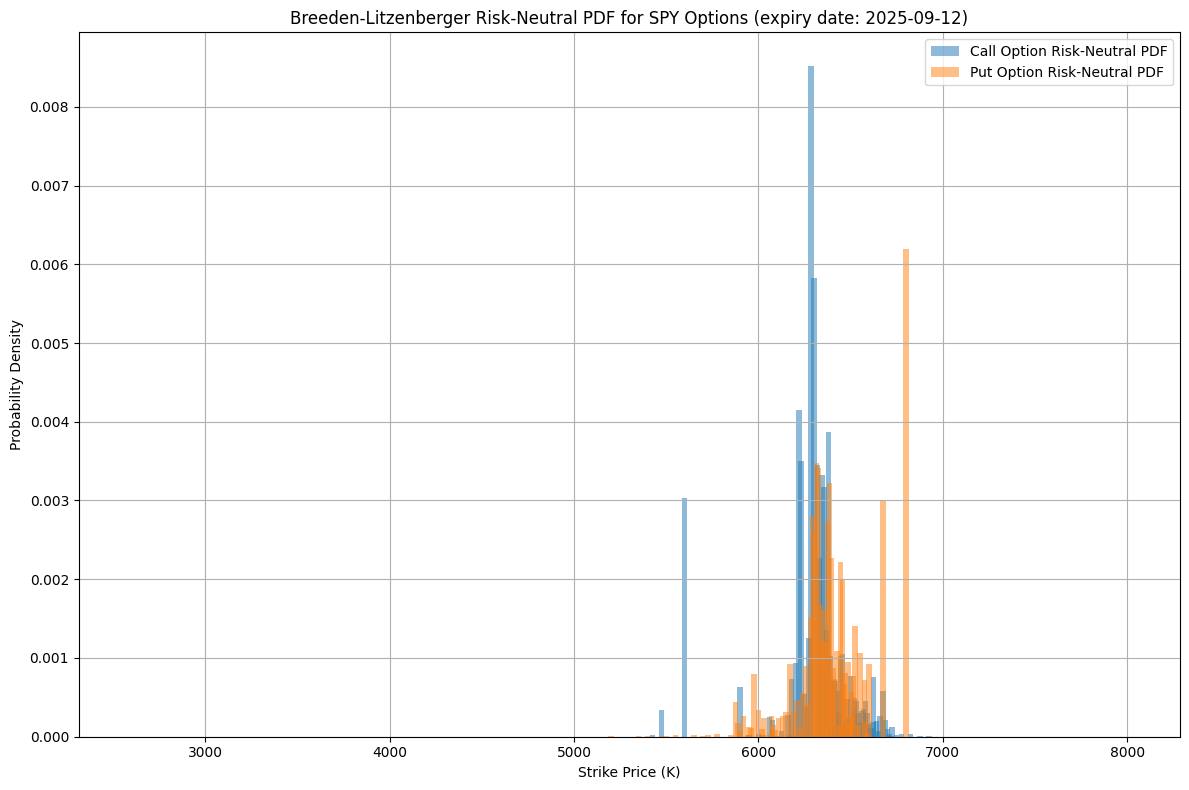

Call Expiry Date: 2025-09-04 # Put Expiry Date: 2025-09-04
Call Mean: 3057.3174
Call Std Dev: 431.3887
Call Skewness: 7.4100
Call Kurtosis: 56.0357
Call Entropy: 2.7520
Call P(Below -1σ): 0.0000
Call P(Above +1σ): 0.0174
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0174
Put Mean: 6606.8267
Put Std Dev: 203.1168
Put Skewness: -2.2298
Put Kurtosis: 16.4929
Put Entropy: 3.1786
Put P(Below -1σ): 0.1576
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0338
Put P(Above +2σ): 0.0000


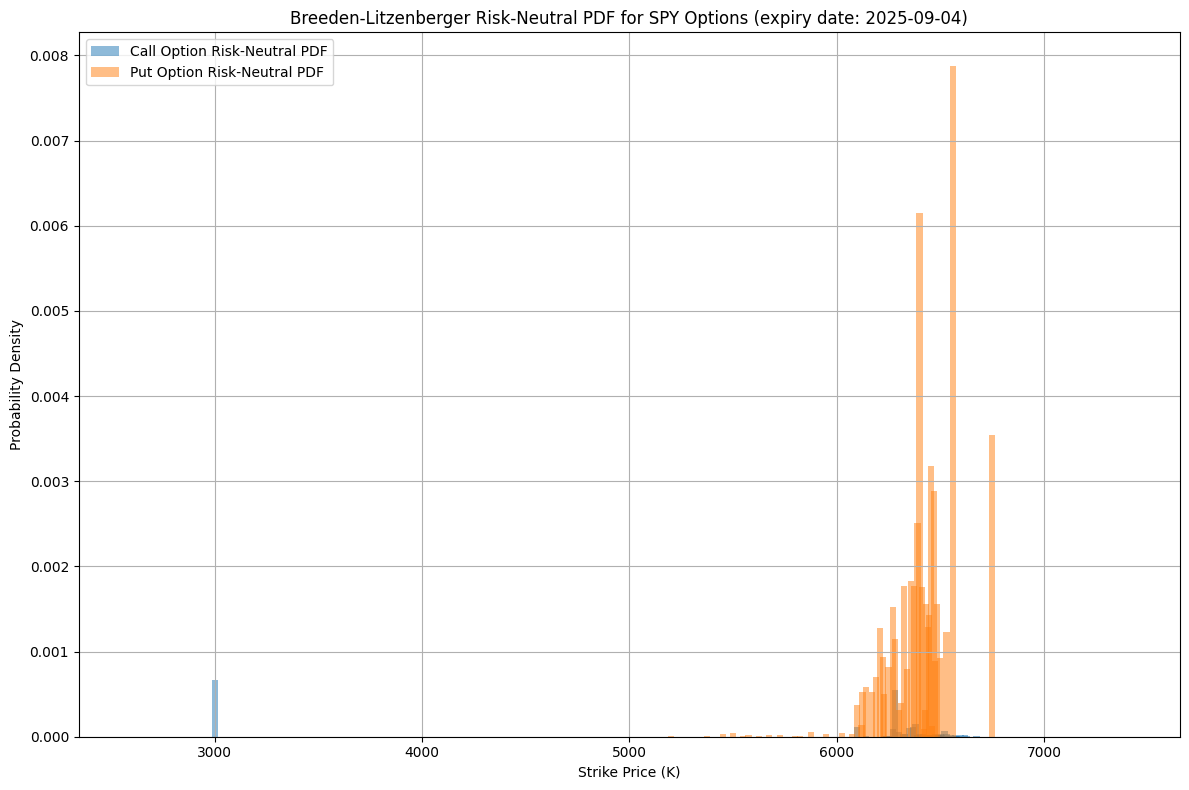

Call Expiry Date: 2025-09-10 # Put Expiry Date: 2025-09-10
Call Mean: 6431.4045
Call Std Dev: 133.0025
Call Skewness: 0.5841
Call Kurtosis: 3.0522
Call Entropy: 3.0517
Call P(Below -1σ): 0.0760
Call P(Above +1σ): 0.1694
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0244
Put Mean: 6396.7081
Put Std Dev: 215.5916
Put Skewness: -3.5918
Put Kurtosis: 28.1924
Put Entropy: 3.2655
Put P(Below -1σ): 0.0955
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0440
Put P(Above +2σ): 0.0000


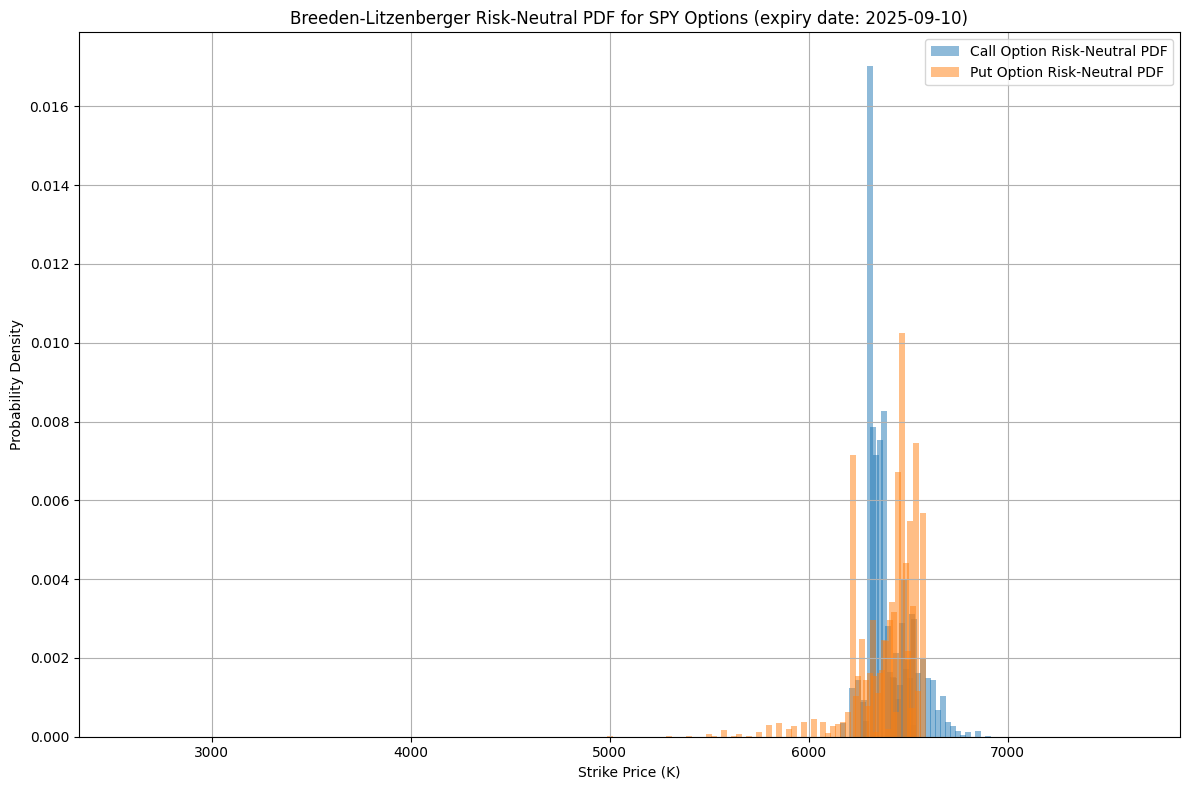

Call Expiry Date: 2025-09-11 # Put Expiry Date: 2025-09-11
Call Mean: 6344.1909
Call Std Dev: 106.8865
Call Skewness: 1.7325
Call Kurtosis: 6.3574
Call Entropy: 2.3717
Call P(Below -1σ): 0.0232
Call P(Above +1σ): 0.1430
Call P(Below -2σ): 0.0042
Call P(Above +2σ): 0.0699
Put Mean: 6776.6278
Put Std Dev: 248.9472
Put Skewness: -1.6404
Put Kurtosis: 11.6799
Put Entropy: 2.8224
Put P(Below -1σ): 0.1258
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0258
Put P(Above +2σ): 0.0000


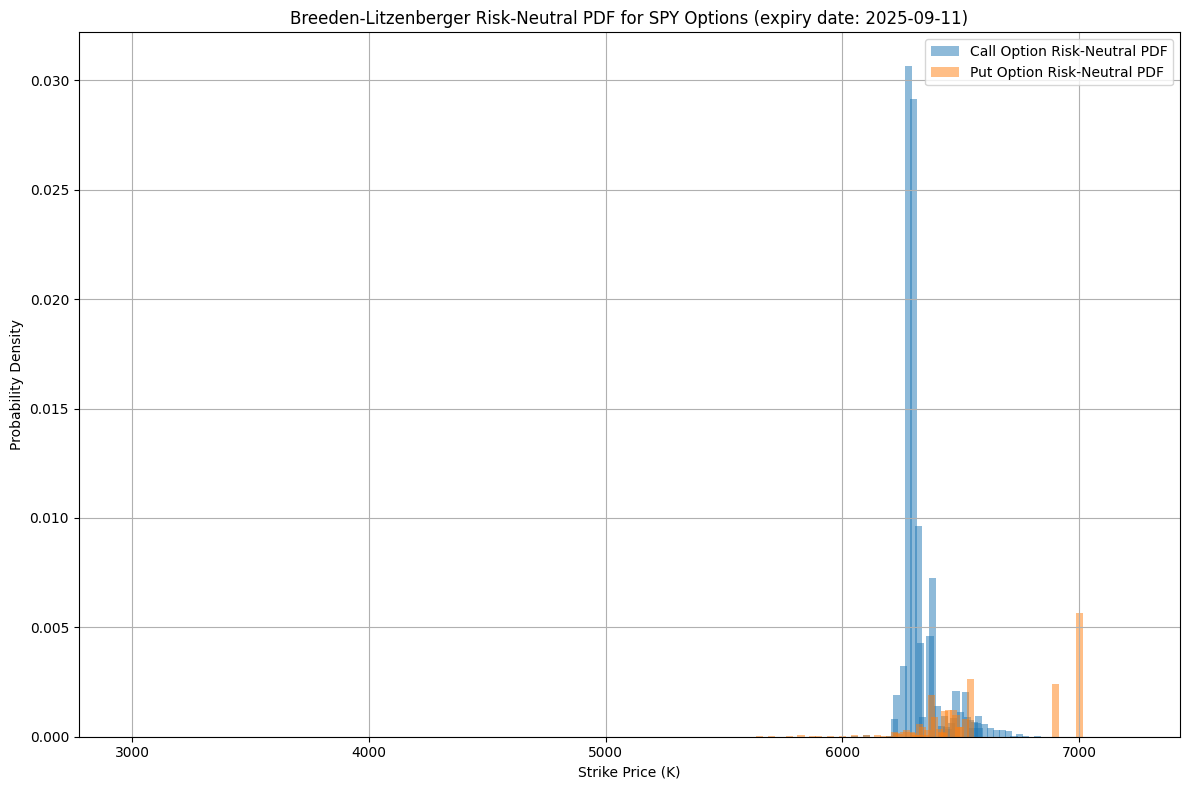

Call Expiry Date: 2025-09-05 # Put Expiry Date: 2025-09-05
Call Mean: 5738.9306
Call Std Dev: 337.4550
Call Skewness: -0.2848
Call Kurtosis: 2.4049
Call Entropy: 2.0965
Call P(Below -1σ): 0.2010
Call P(Above +1σ): 0.2002
Call P(Below -2σ): 0.0021
Call P(Above +2σ): 0.0060
Put Mean: 6720.2731
Put Std Dev: 157.5917
Put Skewness: -1.7703
Put Kurtosis: 20.0613
Put Entropy: 2.7681
Put P(Below -1σ): 0.0631
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0335
Put P(Above +2σ): 0.0000


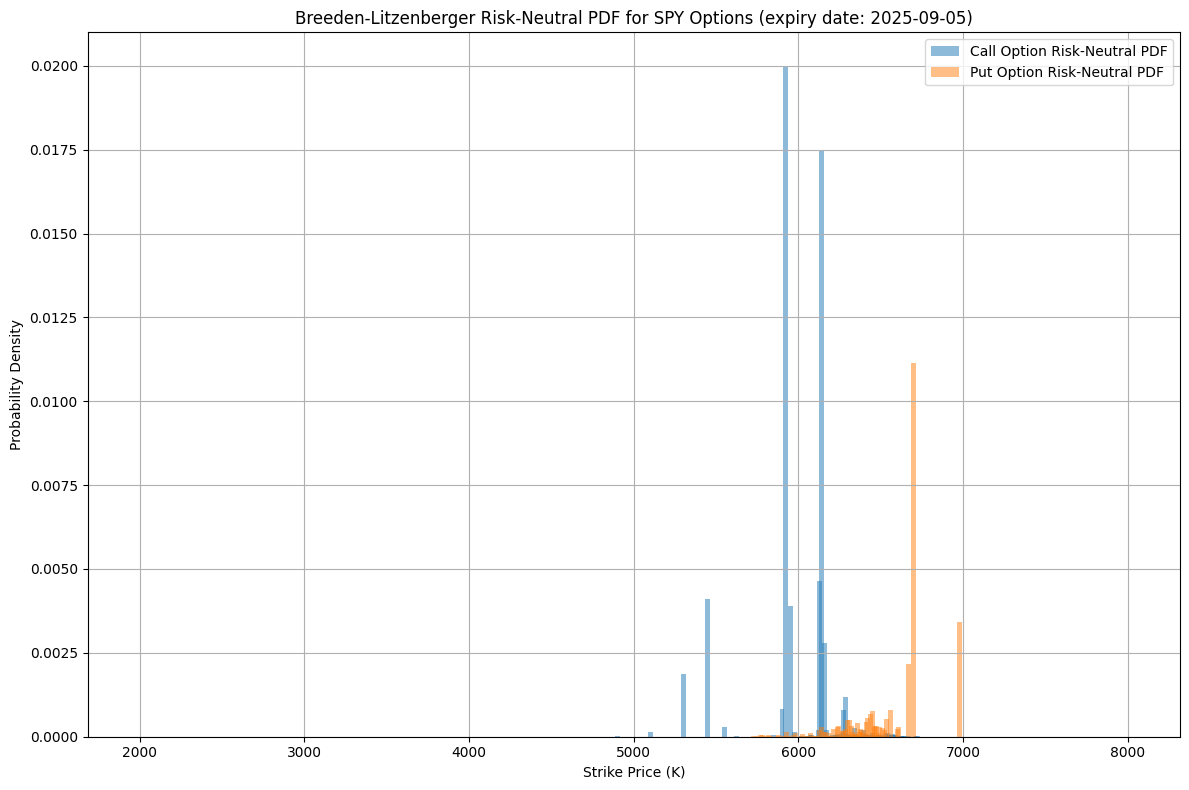

Call Expiry Date: 2025-09-08 # Put Expiry Date: 2025-09-08
Call Mean: 5919.6325
Call Std Dev: 358.1495
Call Skewness: 0.3645
Call Kurtosis: 1.4277
Call Entropy: 2.1186
Call P(Below -1σ): 0.0099
Call P(Above +1σ): 0.2445
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0065
Put Mean: 6720.0501
Put Std Dev: 223.2307
Put Skewness: -2.0258
Put Kurtosis: 13.6764
Put Entropy: 3.1345
Put P(Below -1σ): 0.1640
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0492
Put P(Above +2σ): 0.0000


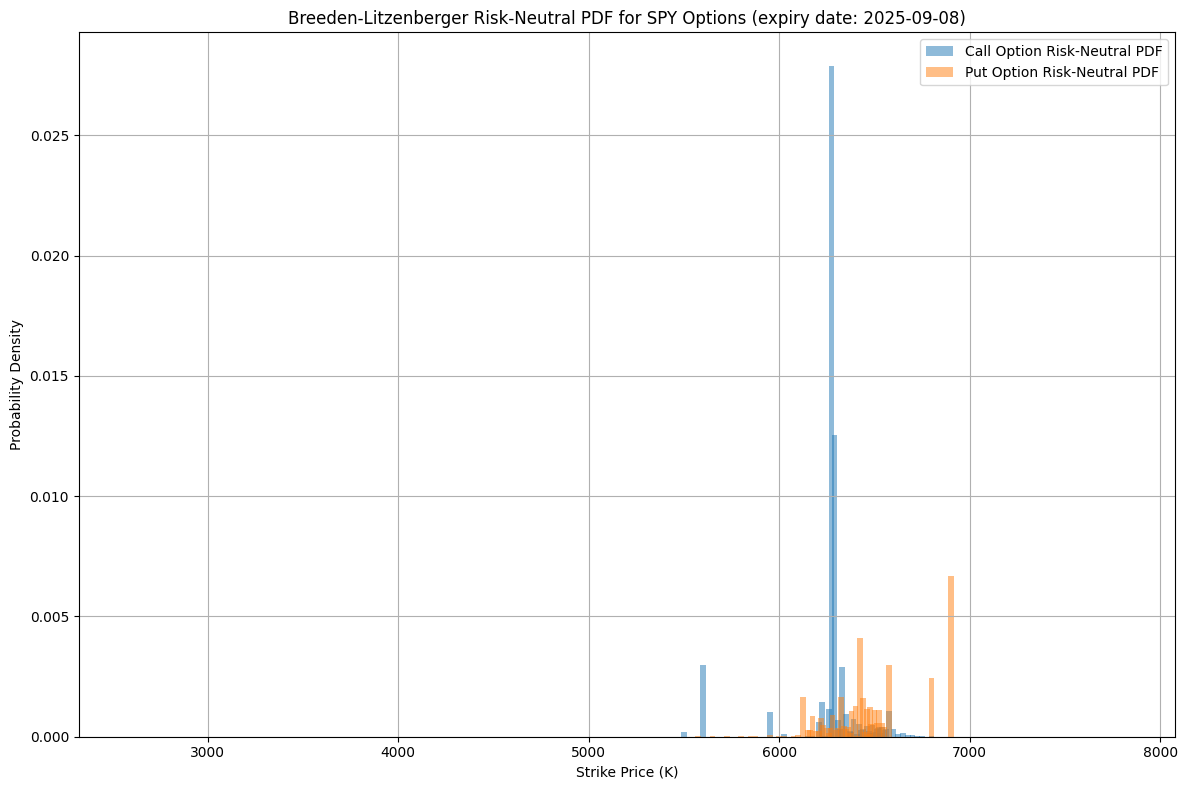

Call Expiry Date: 2025-09-09 # Put Expiry Date: 2025-09-09
Call Mean: 6359.0158
Call Std Dev: 115.7761
Call Skewness: 1.2181
Call Kurtosis: 3.7549
Call Entropy: 2.5495
Call P(Below -1σ): 0.0507
Call P(Above +1σ): 0.2099
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0496
Put Mean: 6413.7514
Put Std Dev: 179.4227
Put Skewness: -5.4993
Put Kurtosis: 59.1252
Put Entropy: 2.9535
Put P(Below -1σ): 0.0878
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0318
Put P(Above +2σ): 0.0000


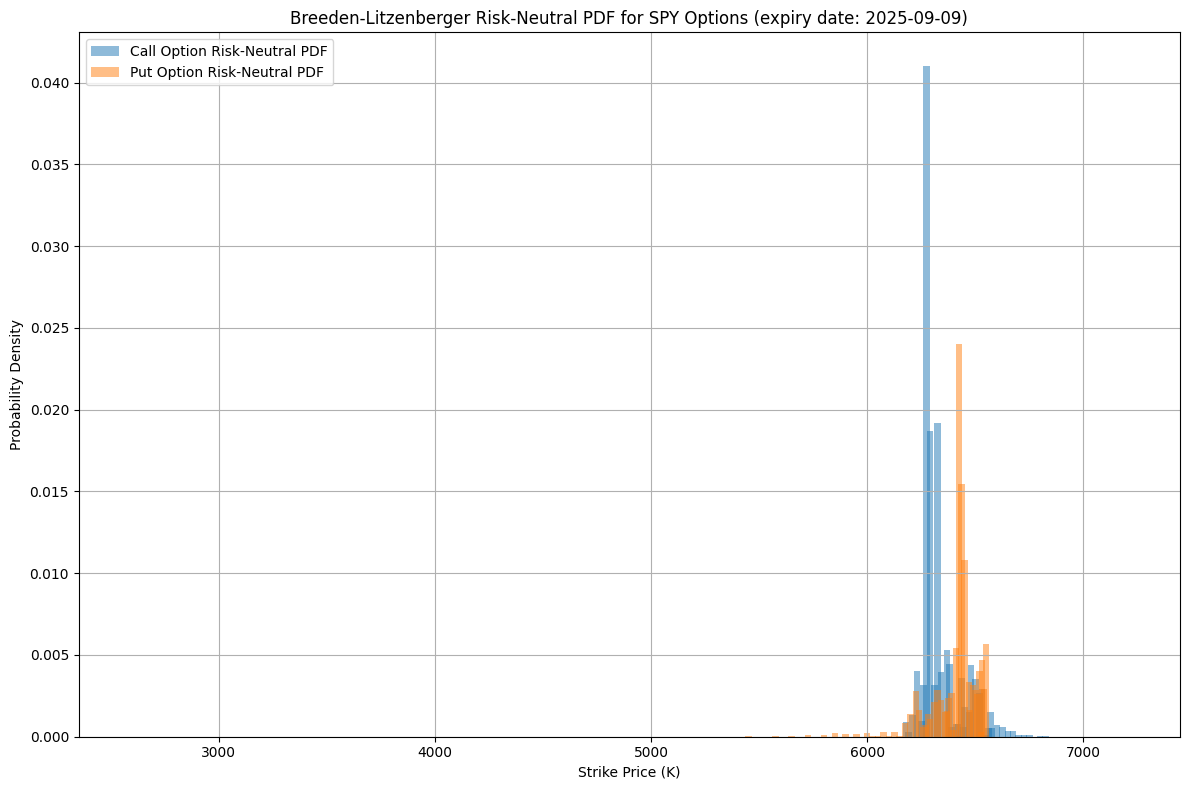

Call Expiry Date: 2025-09-23 # Put Expiry Date: 2025-09-23
Call Mean: 6585.6327
Call Std Dev: 91.8496
Call Skewness: 0.2441
Call Kurtosis: 2.3495
Call Entropy: 2.1113
Call P(Below -1σ): 0.0000
Call P(Above +1σ): 0.0911
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0000
Put Mean: 6217.2274
Put Std Dev: 239.6798
Put Skewness: -2.7957
Put Kurtosis: 14.2129
Put Entropy: 2.2111
Put P(Below -1σ): 0.0385
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0385
Put P(Above +2σ): 0.0000


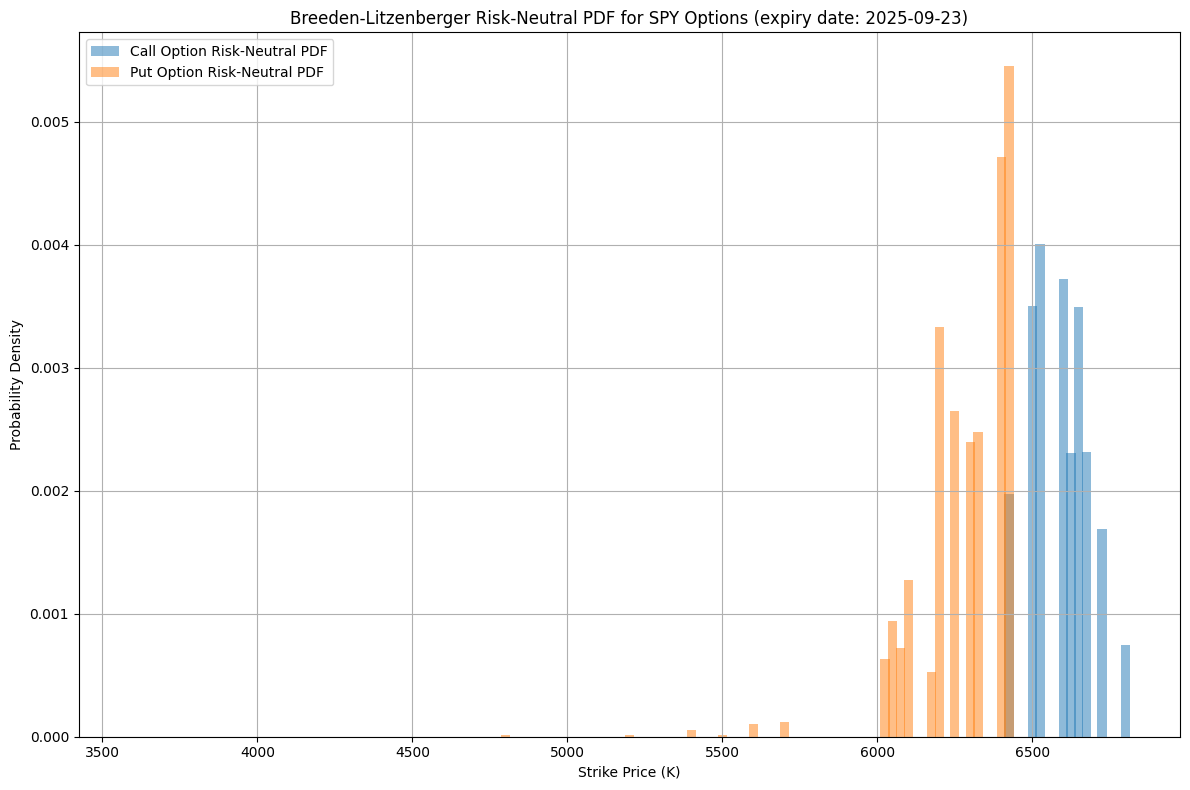

Call Expiry Date: 2025-09-22 # Put Expiry Date: 2025-09-22
Call Mean: 6444.7312
Call Std Dev: 219.8535
Call Skewness: -0.2669
Call Kurtosis: 2.3796
Call Entropy: 3.1120
Call P(Below -1σ): 0.1880
Call P(Above +1σ): 0.1393
Call P(Below -2σ): 0.0105
Call P(Above +2σ): 0.0071
Put Mean: 6430.2648
Put Std Dev: 246.5243
Put Skewness: -4.2984
Put Kurtosis: 39.6612
Put Entropy: 2.9550
Put P(Below -1σ): 0.1028
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0342
Put P(Above +2σ): 0.0000


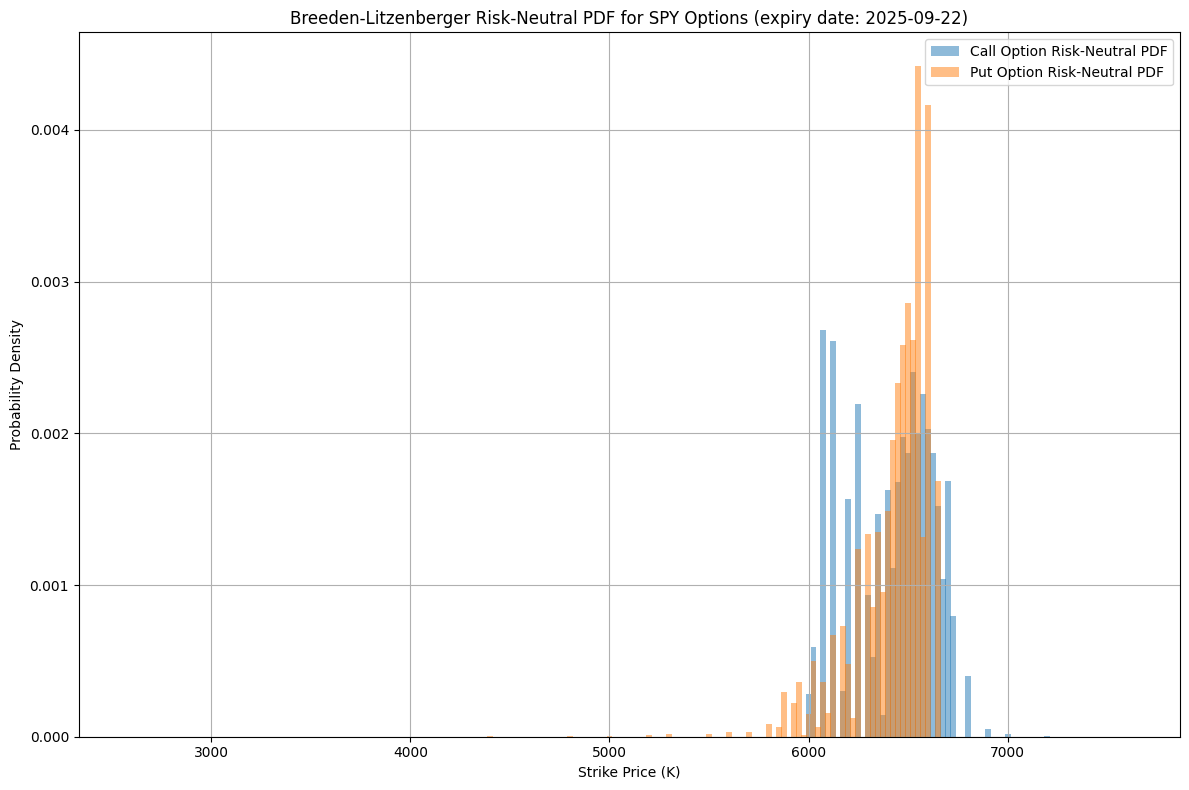

Call Expiry Date: 2025-10-03 # Put Expiry Date: 2025-10-03
Call Mean: 6389.3380
Call Std Dev: 232.9518
Call Skewness: 0.3655
Call Kurtosis: 2.7239
Call Entropy: 3.4400
Call P(Below -1σ): 0.1928
Call P(Above +1σ): 0.1776
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0180
Put Mean: 6403.1644
Put Std Dev: 300.8988
Put Skewness: -1.9995
Put Kurtosis: 15.1644
Put Entropy: 3.6526
Put P(Below -1σ): 0.1243
Put P(Above +1σ): 0.0271
Put P(Below -2σ): 0.0310
Put P(Above +2σ): 0.0000


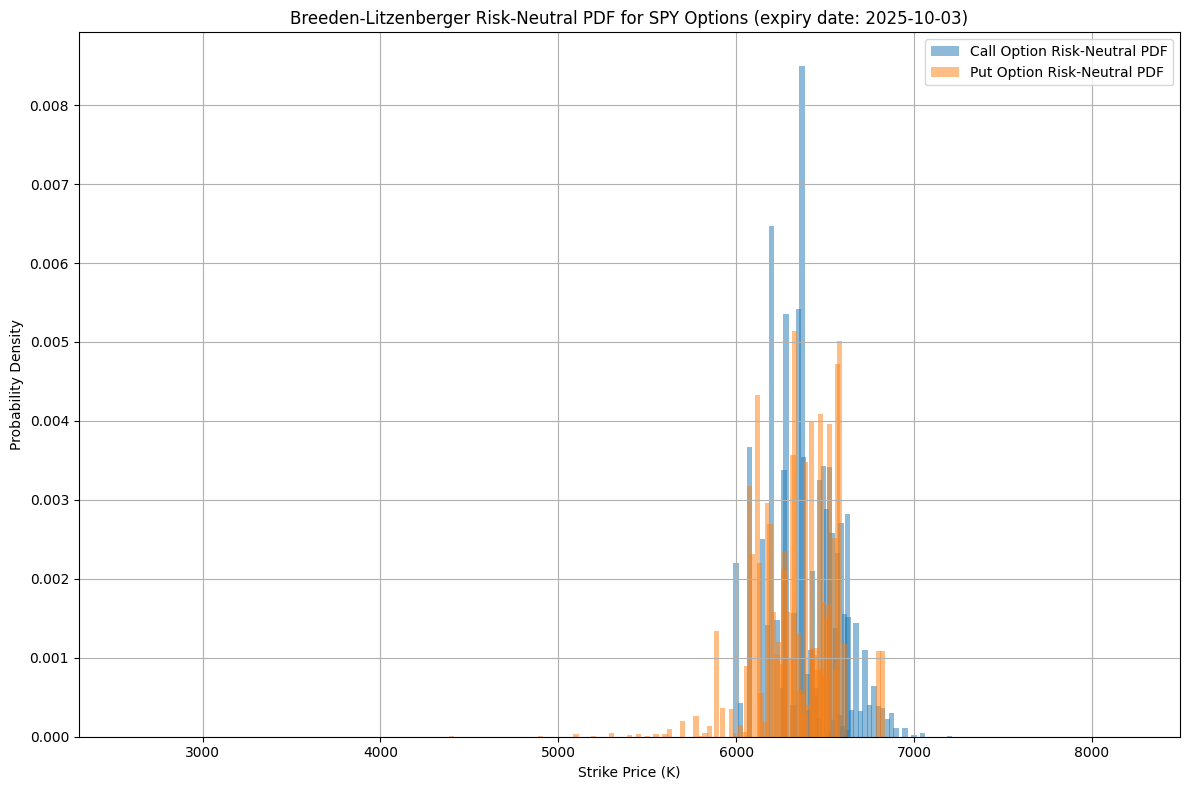

Call Expiry Date: 2025-09-26 # Put Expiry Date: 2025-09-26
Call Mean: 5380.9328
Call Std Dev: 449.5378
Call Skewness: 1.5094
Call Kurtosis: 4.5284
Call Entropy: 3.5575
Call P(Below -1σ): 0.0000
Call P(Above +1σ): 0.1322
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0923
Put Mean: 6300.7597
Put Std Dev: 315.7256
Put Skewness: -3.2058
Put Kurtosis: 26.5798
Put Entropy: 3.7305
Put P(Below -1σ): 0.1219
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0397
Put P(Above +2σ): 0.0000


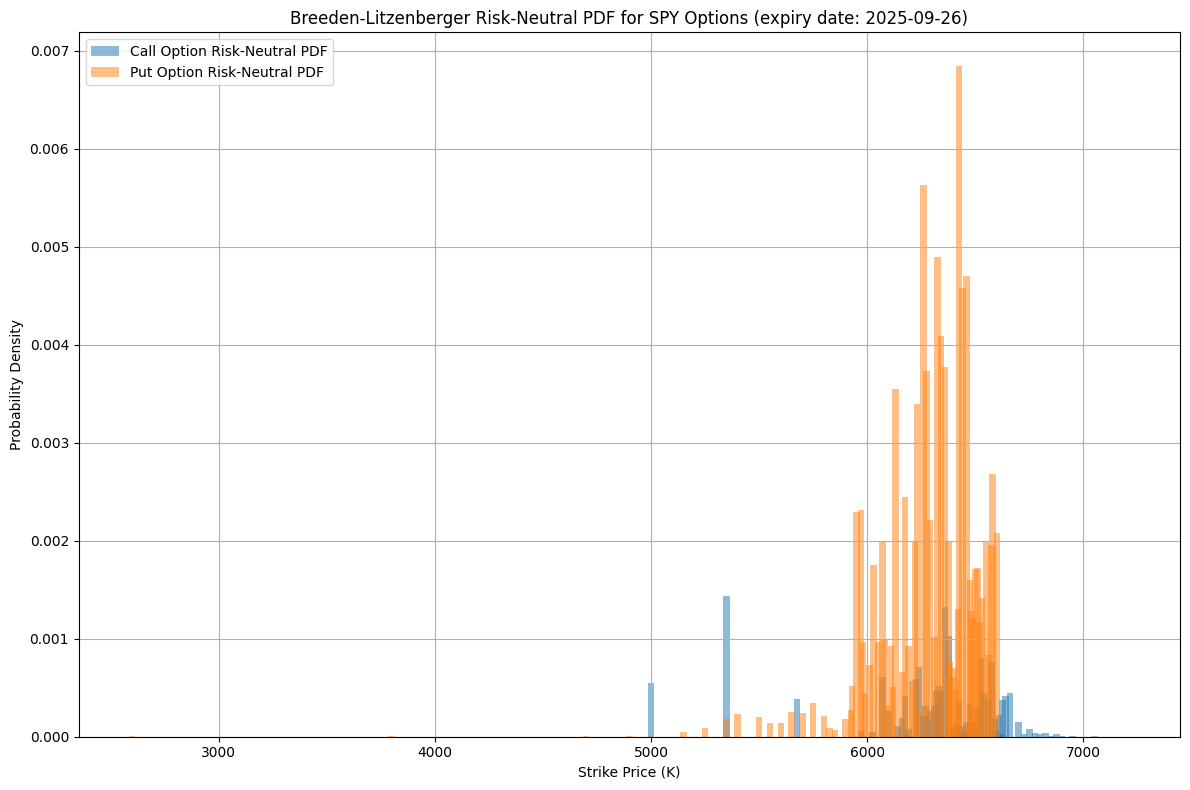

Call Expiry Date: 2025-09-19 # Put Expiry Date: 2025-09-19
Call Mean: 5060.4993
Call Std Dev: 648.9696
Call Skewness: -2.5361
Call Kurtosis: 12.9495
Call Entropy: 3.9181
Call P(Below -1σ): 0.1027
Call P(Above +1σ): 0.0696
Call P(Below -2σ): 0.0400
Call P(Above +2σ): 0.0005
Put Mean: 7475.8399
Put Std Dev: 1228.8739
Put Skewness: 1.9928
Put Kurtosis: 5.9332
Put Entropy: 2.6792
Put P(Below -1σ): 0.0084
Put P(Above +1σ): 0.1455
Put P(Below -2σ): 0.0003
Put P(Above +2σ): 0.1009


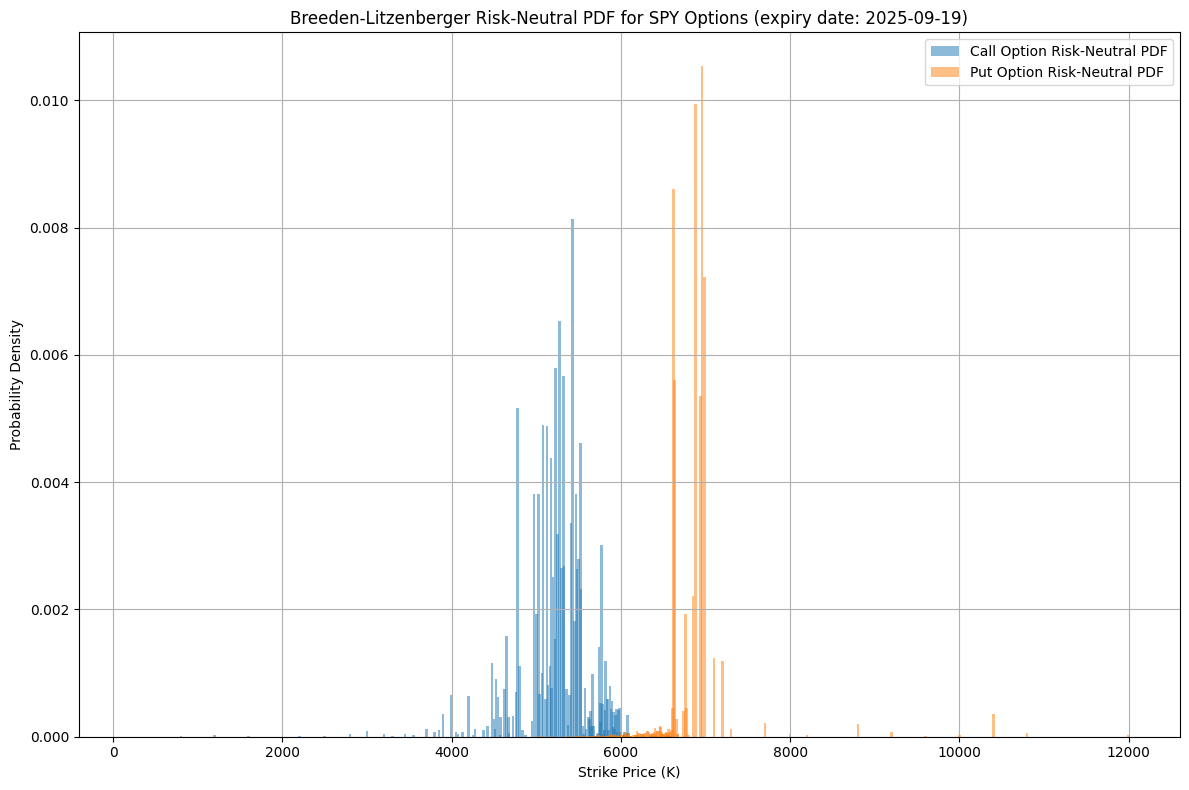

Call Expiry Date: 2025-09-18 # Put Expiry Date: 2025-09-18
Call Mean: 6481.5187
Call Std Dev: 200.6742
Call Skewness: 0.0482
Call Kurtosis: 5.8492
Call Entropy: 2.8891
Call P(Below -1σ): 0.1536
Call P(Above +1σ): 0.0927
Call P(Below -2σ): 0.0391
Call P(Above +2σ): 0.0124
Put Mean: 6408.3132
Put Std Dev: 231.5227
Put Skewness: -5.2833
Put Kurtosis: 60.7013
Put Entropy: 3.0051
Put P(Below -1σ): 0.1045
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0331
Put P(Above +2σ): 0.0000


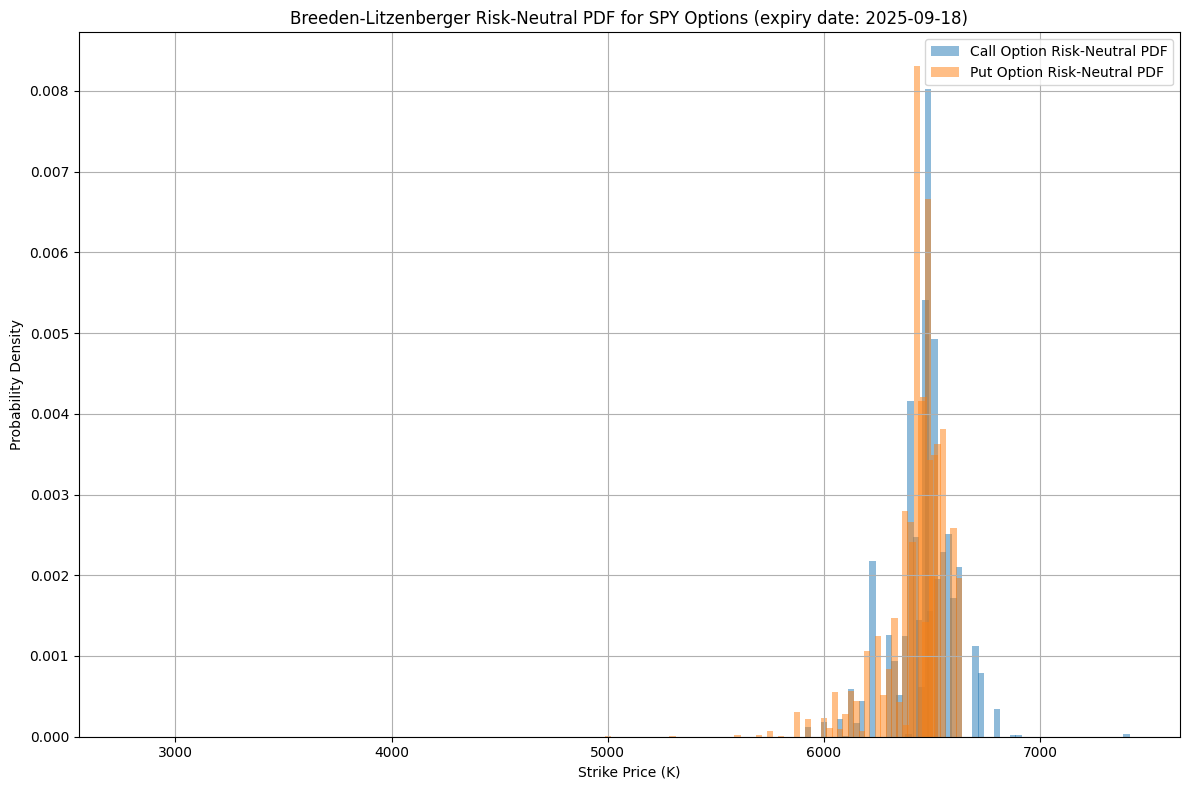

Call Expiry Date: 2025-09-30 # Put Expiry Date: 2025-09-30
Call Mean: 5221.0572
Call Std Dev: 574.1070
Call Skewness: -3.3887
Call Kurtosis: 22.3869
Call Entropy: 4.3028
Call P(Below -1σ): 0.0936
Call P(Above +1σ): 0.0878
Call P(Below -2σ): 0.0154
Call P(Above +2σ): 0.0001
Put Mean: 6531.0361
Put Std Dev: 669.2401
Put Skewness: -1.5903
Put Kurtosis: 4.1894
Put Entropy: 2.8039
Put P(Below -1σ): 0.1707
Put P(Above +1σ): 0.0247
Put P(Below -2σ): 0.1107
Put P(Above +2σ): 0.0000


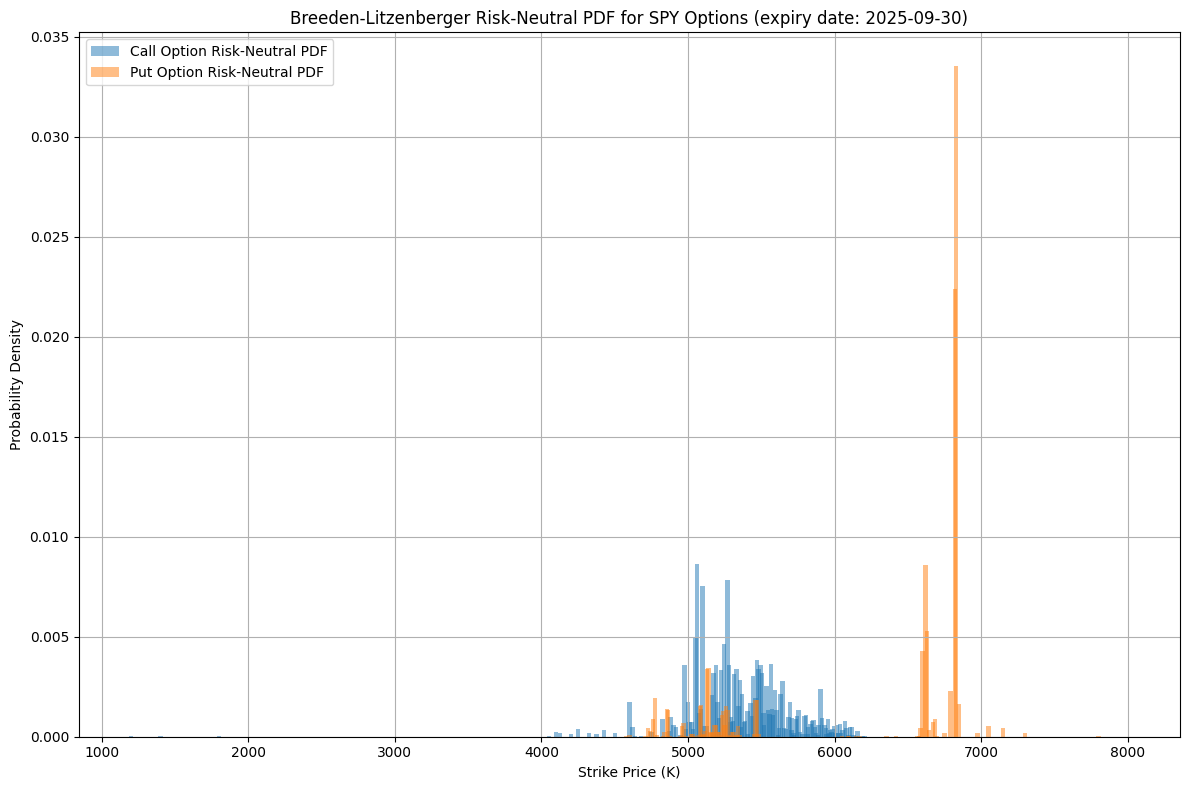

Call Expiry Date: 2025-08-28 # Put Expiry Date: 2025-08-28
Call Mean: 5471.0718
Call Std Dev: 1404.5885
Call Skewness: -1.5405
Call Kurtosis: 3.4044
Call Entropy: 1.1540
Call P(Below -1σ): 0.0000
Call P(Above +1σ): 0.0000
Call P(Below -2σ): 0.0000
Call P(Above +2σ): 0.0000
Put Mean: 6710.4627
Put Std Dev: 191.6329
Put Skewness: -1.1093
Put Kurtosis: 8.5618
Put Entropy: 3.3926
Put P(Below -1σ): 0.1392
Put P(Above +1σ): 0.0000
Put P(Below -2σ): 0.0371
Put P(Above +2σ): 0.0000


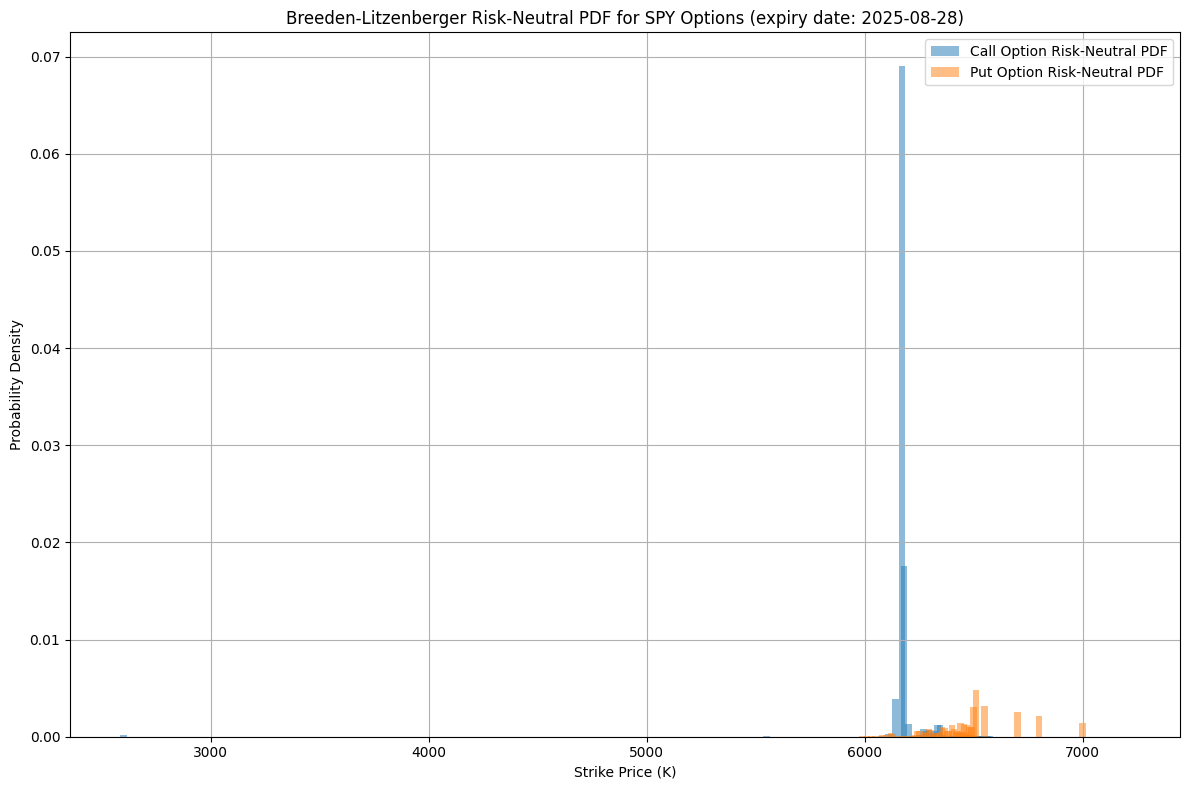

Call Expiry Date: 2025-08-29 # Put Expiry Date: 2025-08-29
Call Mean: 5502.6940
Call Std Dev: 455.3328
Call Skewness: -1.9893
Call Kurtosis: 13.9025
Call Entropy: 4.2147
Call P(Below -1σ): 0.1715
Call P(Above +1σ): 0.1275
Call P(Below -2σ): 0.0194
Call P(Above +2σ): 0.0000
Put Mean: 6809.0785
Put Std Dev: 238.6081
Put Skewness: 1.4860
Put Kurtosis: 6.6370
Put Entropy: 1.7129
Put P(Below -1σ): 0.0054
Put P(Above +1σ): 0.2026
Put P(Below -2σ): 0.0021
Put P(Above +2σ): 0.0581


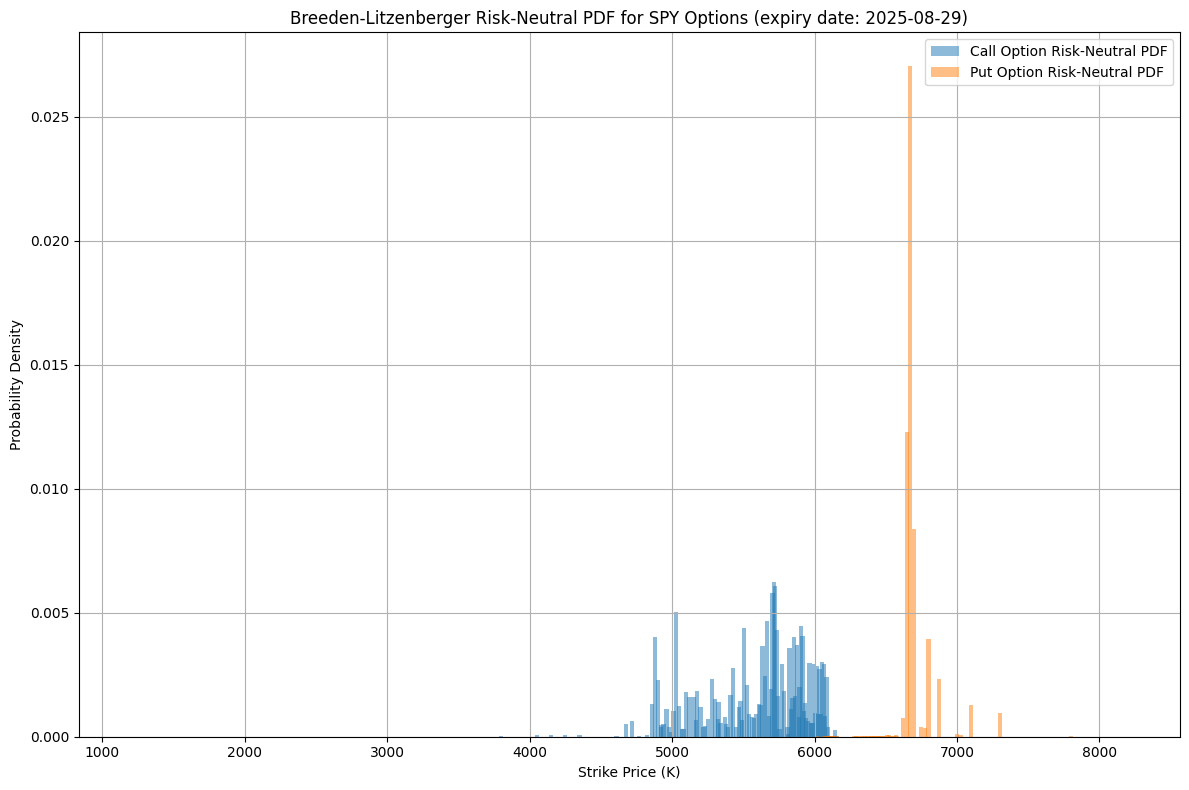

In [9]:
# For Call options
for file_path, D_value in zip(calls_filepaths, calls_dates):
    
    # Loading CSV File
    call_file = pd.read_csv(file_path)
    call_date = D_value

    for file_path1, D_value1 in zip(puts_filepaths, puts_dates):

        # Loading CSV File
        put_file = pd.read_csv(file_path1)
        put_date = D_value1

        if call_date == put_date:
            print("Call Expiry Date:", call_date, "# Put Expiry Date:", put_date)

            Dates.append(call_date)

            # Define the risk-free rate and time to expiration
            risk_free_rate = 0.0492 # 30-year US bond yield
            
            date1 = pd.to_datetime("2025-08-19")
            date2 = pd.to_datetime(call_date)

            delta = (date2 - date1).days
            T = delta / 365 # Time to expiration


            # Use mid-price of call option (to smooth out bid/ask noise)
            call_file["mid"] = (call_file["bid"] + call_file["ask"]) / 2
            put_file["mid"] = (put_file["bid"] + put_file["ask"]) / 2

            # Sort by strike
            call_options = call_file.sort_values("strike").dropna(subset=["mid"])
            put_options = put_file.sort_values("strike").dropna(subset=["mid"])

            call_strikes = call_options["strike"].values
            call_prices = call_options["mid"].values
            put_strikes = put_options["strike"].values
            put_prices = put_options["mid"].values

            # === Step 1: Smooth call price curve ===
            call_spline = CubicSpline(call_strikes, call_prices)
            put_spline = CubicSpline(put_strikes, put_prices)


            # === Step 2: Compute second derivative ===
            call_second_derivative = call_spline.derivative(2)(call_strikes)
            put_second_derivative = put_spline.derivative(2)(put_strikes)


            # === Step 3: Risk-neutral PDF ===
            call_pdf = np.exp(risk_free_rate*T) * call_second_derivative
            put_pdf = np.exp(risk_free_rate*T) * put_second_derivative
  
            # enforce positivity
            call_pdf = np.maximum(call_pdf, 0)
            put_pdf = np.maximum(put_pdf, 0) 

            # Normalize to sum to 1
            call_pdf /= np.trapezoid(call_pdf, call_strikes)
            put_pdf /= np.trapezoid(put_pdf, put_strikes)


            # === Step 4: Compute statistics ===
            call_mean = np.trapezoid(call_strikes * call_pdf, call_strikes)
            put_mean = np.trapezoid(put_strikes * put_pdf, put_strikes)

            call_var = np.trapezoid((call_strikes - call_mean)**2 * call_pdf, call_strikes)
            put_var = np.trapezoid((put_strikes - put_mean)**2 * put_pdf, put_strikes)

            call_std = np.sqrt(call_var)
            put_std = np.sqrt(put_var)

            call_skew = np.trapezoid(((call_strikes - call_mean)/call_std)**3 * call_pdf, call_strikes)
            put_skew = np.trapezoid(((put_strikes - put_mean)/put_std)**3 * put_pdf, put_strikes)

            call_kurt = np.trapezoid(((call_strikes - call_mean)/call_std)**4 * call_pdf, call_strikes)
            put_kurt = np.trapezoid(((put_strikes - put_mean)/put_std)**4 * put_pdf, put_strikes)

            # Shannon entropy (natural log base)
            call_entropy = entropy(call_pdf)
            put_entropy = entropy(put_pdf)

            # Tail probabilities: below -1σ, above +1σ, etc.
            call_p_below_1sigma = np.trapezoid(call_pdf[call_strikes < call_mean - call_std], call_strikes[call_strikes < call_mean - call_std])
            call_p_above_1sigma = np.trapezoid(call_pdf[call_strikes > call_mean + call_std], call_strikes[call_strikes > call_mean + call_std])

            put_p_below_1sigma = np.trapezoid(put_pdf[put_strikes < put_mean - put_std], put_strikes[put_strikes < put_mean - put_std])
            put_p_above_1sigma = np.trapezoid(put_pdf[put_strikes > put_mean + put_std], put_strikes[put_strikes > put_mean + put_std])


            call_p_below_2sigma = np.trapezoid(call_pdf[call_strikes < call_mean - 2*call_std], call_strikes[call_strikes < call_mean - 2*call_std])
            call_p_above_2sigma = np.trapezoid(call_pdf[call_strikes > call_mean + 2*call_std], call_strikes[call_strikes > call_mean + 2*call_std])

            put_p_below_2sigma = np.trapezoid(put_pdf[put_strikes < put_mean - 2*put_std], put_strikes[put_strikes < put_mean - 2*put_std])
            put_p_above_2sigma = np.trapezoid(put_pdf[put_strikes > put_mean + 2*put_std], put_strikes[put_strikes > put_mean + 2*put_std])



            call_mean_rn.append(call_mean)
            put_mean_rn.append(put_mean)

            call_var_rn.append(call_var)
            put_var_rn.append(put_var)

            call_std_rn.append(call_std)
            put_std_rn.append(put_std)

            call_skew_rn.append(call_skew)
            put_skew_rn.append(put_skew)

            call_kurt_rn.append(call_kurt)
            put_kurt_rn.append(put_kurt)

            call_entropy_rn.append(call_entropy)
            put_entropy_rn.append(put_entropy)

            ###

            call_p_below_1sigma_rn.append(call_p_below_1sigma)
            call_p_above_1sigma_rn.append(call_p_above_1sigma)

            put_p_below_1sigma_rn.append(put_p_below_1sigma)
            put_p_above_1sigma_rn.append(put_p_above_1sigma)

            call_p_below_2sigma_rn.append(call_p_below_2sigma)
            call_p_above_2sigma_rn.append(call_p_above_2sigma)

            put_p_below_2sigma_rn.append(put_p_below_2sigma)
            put_p_above_2sigma_rn.append(put_p_above_2sigma)



            # === Output ===
            results = {
                "Call Mean": call_mean,
                "Call Std Dev": call_std,
                "Call Skewness": call_skew,
                "Call Kurtosis": call_kurt,
                "Call Entropy": call_entropy,
                "Call P(Below -1σ)": call_p_below_1sigma,
                "Call P(Above +1σ)": call_p_above_1sigma,
                "Call P(Below -2σ)": call_p_below_2sigma,
                "Call P(Above +2σ)": call_p_above_2sigma,
                "Put Mean": put_mean,
                "Put Std Dev": put_std,
                "Put Skewness": put_skew,
                "Put Kurtosis": put_kurt,
                "Put Entropy": put_entropy,
                "Put P(Below -1σ)": put_p_below_1sigma,
                "Put P(Above +1σ)": put_p_above_1sigma,
                "Put P(Below -2σ)": put_p_below_2sigma,
                "Put P(Above +2σ)": put_p_above_2sigma                
            }

            for k,v in results.items():
                print(f"{k}: {v:.4f}")



            # Plot the risk-neutral PDF
            pt.figure(figsize=(12, 8))
            pt.bar(call_strikes, call_pdf, width=30, alpha=0.5, label='Call Option Risk-Neutral PDF')
            pt.bar(put_strikes, put_pdf, width=30, alpha=0.5, label='Put Option Risk-Neutral PDF')
            pt.title(f'Breeden-Litzenberger Risk-Neutral PDF for SPY Options (expiry date: {call_date})')
            pt.xlabel('Strike Price (K)')
            pt.ylabel('Probability Density')
            pt.grid(True)
            pt.legend()
            pt.tight_layout()
            pt.show()

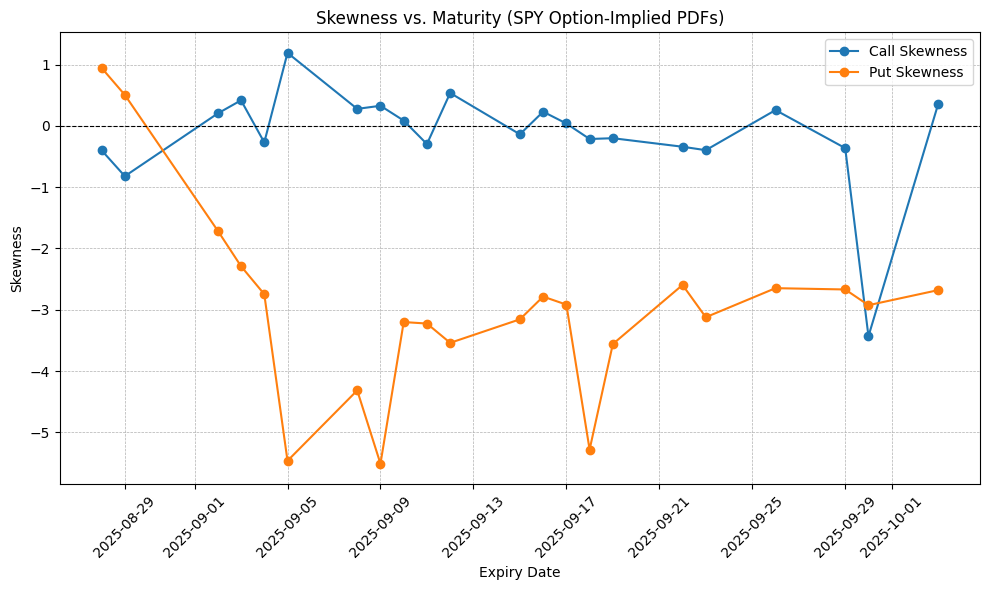

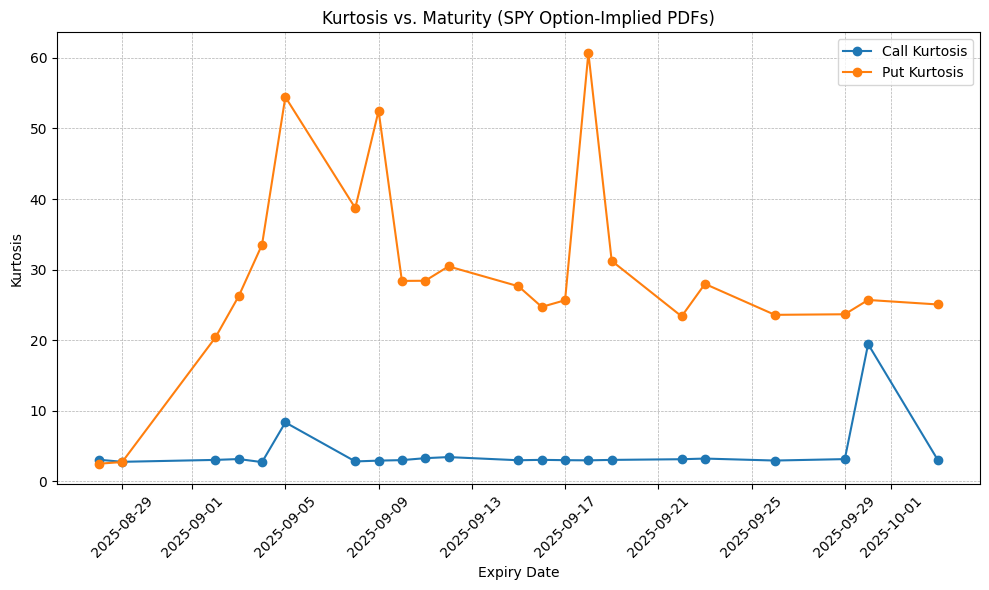

In [10]:
data_moments = [
    ("2025-08-28", -0.3979, 0.9467, 3.0723, 2.5081),
    ("2025-08-29", -0.8202, 0.5060, 2.7772, 2.7477),
    ("2025-09-02", 0.2041, -1.7108, 3.0484, 20.3891),
    ("2025-09-03", 0.4181, -2.2895, 3.1661, 26.2426),
    ("2025-09-04", -0.2691, -2.7460, 2.7352, 33.5294),
    ("2025-09-05", 1.1923, -5.4653, 8.3565, 54.4550),
    ("2025-09-08", 0.2784, -4.3159, 2.8306, 38.7216),
    ("2025-09-09", 0.3290, -5.5125, 2.9451, 52.4954),
    ("2025-09-10", 0.0874, -3.2007, 3.0164, 28.4005),
    ("2025-09-11", -0.2956, -3.2249, 3.2929, 28.4230),
    ("2025-09-12", 0.5377, -3.5400, 3.4473, 30.4600),
    ("2025-09-15", -0.1366, -3.1562, 2.9981, 27.6424),
    ("2025-09-16", 0.2322, -2.7852, 3.0547, 24.7207),
    ("2025-09-17", 0.0399, -2.9160, 3.0096, 25.6640),
    ("2025-09-18", -0.2133, -5.2817, 2.9847, 60.7013),
    ("2025-09-19", -0.2002, -3.5593, 3.0485, 31.2361),
    ("2025-09-22", -0.3395, -2.5951, 3.1438, 23.3807),
    ("2025-09-23", -0.3957, -3.1220, 3.2369, 27.9780),
    ("2025-09-26", 0.2587, -2.6476, 2.9572, 23.5952),
    ("2025-09-29", -0.3620, -2.6689, 3.1596, 23.6757),
    ("2025-09-30", -3.4325, -2.9255, 19.4480, 25.7020),
    ("2025-10-03", 0.3569, -2.6795, 2.9837, 25.0636),
]

df_mom = pd.DataFrame(data_moments, columns=["expiry_date", "call_skew", "put_skew", "call_kurt", "put_kurt"])
df_mom["expiry_date"] = pd.to_datetime(df_mom["expiry_date"])
df_mom = df_mom.sort_values("expiry_date").reset_index(drop=True)

# Skewness plot
pt.figure(figsize=(10,6))
pt.plot(df_mom["expiry_date"], df_mom["call_skew"], marker="o", label="Call Skewness")
pt.plot(df_mom["expiry_date"], df_mom["put_skew"], marker="o", label="Put Skewness")
pt.axhline(0, color="black", linewidth=0.8, linestyle="--")
pt.xlabel("Expiry Date")
pt.ylabel("Skewness")
pt.title("Skewness vs. Maturity (SPY Option-Implied PDFs)")
pt.legend()
pt.grid(True, linestyle="--", linewidth=0.5)
pt.xticks(rotation=45)
pt.tight_layout()
pt.show()

# Kurtosis plot
pt.figure(figsize=(10,6))
pt.plot(df_mom["expiry_date"], df_mom["call_kurt"], marker="o", label="Call Kurtosis")
pt.plot(df_mom["expiry_date"], df_mom["put_kurt"], marker="o", label="Put Kurtosis")
pt.xlabel("Expiry Date")
pt.ylabel("Kurtosis")
pt.title("Kurtosis vs. Maturity (SPY Option-Implied PDFs)")
pt.legend()
pt.grid(True, linestyle="--", linewidth=0.5)
pt.xticks(rotation=45)
pt.tight_layout()
pt.show()

In [11]:
index_file = pd.read_csv("/Users/dhaneshg/Downloads/Dhanesh/data/SPX.csv", skiprows=[1,2])
index_file.rename(columns={"Price": "Date"}, inplace=True)

index = index_file.copy()

index["Returns"] = (index["Close"]/index["Close"].shift(1)) - 1
returns = index["Returns"].dropna()

# --- KDE-based entropy function ---
def shannon_entropy_kde(data, bandwidth=None, grid_points=200):
    # Fit KDE
    kde = gaussian_kde(data, bw_method=bandwidth)
    
    # Build grid over data range
    xmin, xmax = data.min(), data.max()
    xs = np.linspace(xmin, xmax, grid_points)
    
    # Evaluate density
    pdf = kde(xs)
    
    # Shannon entropy (numerical integration of -f(x) log f(x))
    eps = 1e-12
    entropy_integrand = pdf * np.log(pdf + eps)
    H = simpson(entropy_integrand, x=xs)  # integral over xs
    return H

# Example: compute entropy of all returns
H_total = shannon_entropy_kde(returns, bandwidth="scott")
print("Index Values:")
print("KDE Shannon Entropy (all returns):", H_total)

# rolling entropy (20-day trading window), for Trading strategies
window = 20
rolling_entropy = []
for i in range(len(returns)):
    if i < window:
        rolling_entropy.append(np.nan)
    else:
        H = shannon_entropy_kde(returns.iloc[i-window:i], bandwidth="scott")
        rolling_entropy.append(H)

index = index.iloc[1:].reset_index(drop=True)  # align lengths
index["Rolling_Entropy_KDE"] = rolling_entropy



# --- Basic moments ---
mean_ret = np.mean(returns)
annualised_mean = mean_ret*252
std_ret = np.std(returns, ddof=1)   # sample std dev
skew_ret = skew(returns)
kurt_ret = kurtosis(returns, fisher=False, bias=False)

# --- Tail probabilities ---
p_below_1 = np.mean(returns < (mean_ret - std_ret))
p_above_1 = np.mean(returns > (mean_ret + std_ret))
p_below_2 = np.mean(returns < (mean_ret - 2*std_ret))
p_above_2 = np.mean(returns > (mean_ret + 2*std_ret))

# --- Collect in a dictionary / DataFrame ---
stats_summary = {
    "Annualised Returns": annualised_mean,
    "Mean Returns": mean_ret,
    "Std Dev": std_ret,
    "Skewness": skew_ret,
    "Kurtosis": kurt_ret,
    "P(Below -1σ)": p_below_1,
    "P(Above +1σ)": p_above_1,
    "P(Below -2σ)": p_below_2,
    "P(Above +2σ)": p_above_2
}

for k,v in stats_summary.items():
    print(f"{k}: {v:.4f}")

Index Values:
KDE Shannon Entropy (all returns): 3.0217632174230644
Annualised Returns: 0.1449
Mean Returns: 0.0006
Std Dev: 0.0135
Skewness: -0.3184
Kurtosis: 16.4175
P(Below -1σ): 0.1009
P(Above +1σ): 0.0967
P(Below -2σ): 0.0275
P(Above +2σ): 0.0141



 Regression 1: σ_impl vs Risk-neutral Features
                            OLS Regression Results                            
Dep. Variable:             sigma_impl   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.7549
Date:                Sat, 30 Aug 2025   Prob (F-statistic):              0.526
Time:                        16:57:24   Log-Likelihood:                -309.71
No. Observations:                  44   AIC:                             627.4
Df Residuals:                      40   BIC:                             634.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

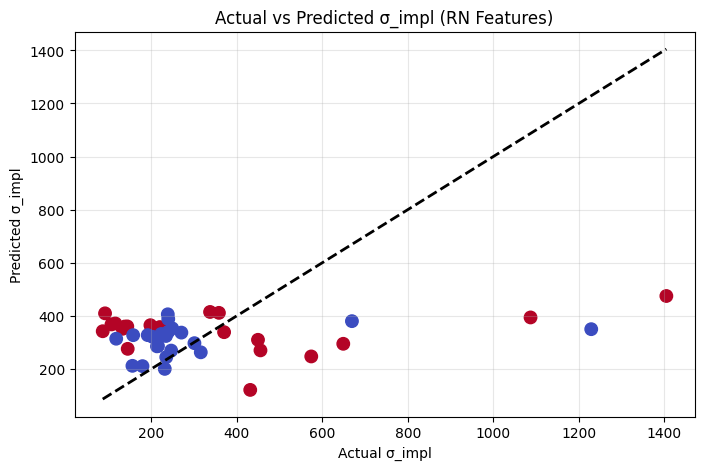


 Regression 2: σ_impl vs Delta Features
                            OLS Regression Results                            
Dep. Variable:             sigma_impl   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.7549
Date:                Sat, 30 Aug 2025   Prob (F-statistic):              0.526
Time:                        16:57:24   Log-Likelihood:                -309.71
No. Observations:                  44   AIC:                             627.4
Df Residuals:                      40   BIC:                             634.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

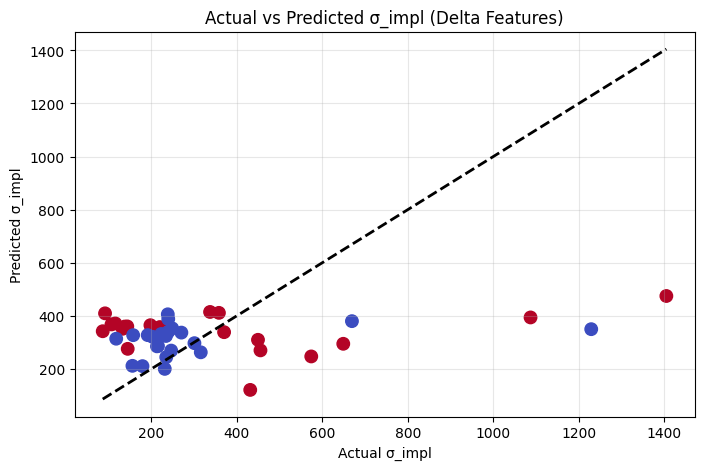

In [12]:
# Empirical (index) features

H_emp     = H_total
Skew_emp  = skew_ret
Kurt_emp  = kurt_ret
Tail1_emp = p_below_1 + p_above_1   # P(below -1σ) + P(above +1σ)
Tail2_emp = p_below_2 + p_above_2   # P(below -2σ) + P(above +2σ)
mu_real   = mean_ret            # mean return (daily)


# Risk-neutral values (Calls + Puts)

columns = [
    "expiry", "mu_RN", "sigma_impl", "H_RN", "Skew_RN", "Kurt_RN", "type"
]
df = pd.DataFrame(columns=columns)

# Fill call rows
df_calls = pd.DataFrame({
    "expiry": Dates,
    "mu_RN": call_mean_rn,
    "sigma_impl": call_std_rn,
    "H_RN": call_entropy_rn,
    "Skew_RN": call_skew_rn,
    "Kurt_RN": call_kurt_rn,
    "type": "call"
})

# Fill put rows
df_puts = pd.DataFrame({
    "expiry": Dates,
    "mu_RN": put_mean_rn,
    "sigma_impl": put_std_rn,
    "H_RN": put_entropy_rn,
    "Skew_RN": put_skew_rn,
    "Kurt_RN": put_kurt_rn,
    "type": "put"
})

# Combine the Data Frames
df = pd.concat([df_calls, df_puts], ignore_index=True)


# Add empirical features (same across all rows here)
df["H_emp"]     = H_emp
df["Skew_emp"]  = Skew_emp
df["Kurt_emp"]  = Kurt_emp
df["Tail1_emp"] = Tail1_emp
df["Tail2_emp"] = Tail2_emp
df["mu_real"]   = mu_real
df["delta_H"]    = df["H_emp"] - df["H_RN"]
df["delta_Skew"] = df["Skew_emp"] - df["Skew_RN"]
df["delta_Kurt"] = df["Kurt_emp"] - df["Kurt_RN"]



# Regression 1: Risk-neutral features
X1 = df[["H_RN", "Skew_RN", "Kurt_RN"]]
y1 = df["sigma_impl"]

X1 = sm.add_constant(X1)
model1 = sm.OLS(y1, X1).fit()

print("\n Regression 1: σ_impl vs Risk-neutral Features")
print(model1.summary())

model1 = LinearRegression()
model1.fit(X1, y1)

print("\n Regression 1: σ_impl vs Risk-neutral Features")
print("Intercept:", model1.intercept_)
print("Coefficients:", dict(zip(X1.columns, model1.coef_)))
print("R^2:", model1.score(X1, y1))

# Plot fitted vs actual
df["sigma_impl_pred_RN"] = model1.predict(X1)
pt.figure(figsize=(8,5))
pt.scatter(df["sigma_impl"], df["sigma_impl_pred_RN"], 
            c=(df["type"]=="call"), cmap="coolwarm", s=80)
pt.plot([df["sigma_impl"].min(), df["sigma_impl"].max()],
         [df["sigma_impl"].min(), df["sigma_impl"].max()], 'k--', lw=2)
pt.xlabel("Actual σ_impl")
pt.ylabel("Predicted σ_impl")
pt.title("Actual vs Predicted σ_impl (RN Features)")
pt.grid(alpha=0.3)
pt.show()


# Regression 2: Delta features
X2 = df[["delta_H", "delta_Skew", "delta_Kurt"]]
y2 = df["sigma_impl"]

X2 = sm.add_constant(X2)
model2 = sm.OLS(y2, X2).fit()

print("\n Regression 2: σ_impl vs Delta Features")
print(model2.summary())

model2 = LinearRegression()
model2.fit(X2, y2)

print("\n Regression 2: σ_impl vs Delta Features")
print("Intercept:", model2.intercept_)
print("Coefficients:", dict(zip(X2.columns, model2.coef_)))
print("R^2:", model2.score(X2, y2))

# Plot fitted vs actual
df["sigma_impl_pred_delta"] = model2.predict(X2)
pt.figure(figsize=(8,5))
pt.scatter(df["sigma_impl"], df["sigma_impl_pred_delta"], 
            c=(df["type"]=="call"), cmap="coolwarm", s=80)
pt.plot([df["sigma_impl"].min(), df["sigma_impl"].max()],
         [df["sigma_impl"].min(), df["sigma_impl"].max()], 'k--', lw=2)
pt.xlabel("Actual σ_impl")
pt.ylabel("Predicted σ_impl")
pt.title("Actual vs Predicted σ_impl (Delta Features)")
pt.grid(alpha=0.3)
pt.show()

Lognormal fit params: m = 8.773710453488983  s = 0.048008437896818835
P(S_T <= 6466.91) = 0.5062
Sim mean (sim): 6469.3922303096  quantiles: [5779.37736118 5975.84332117 6273.02692884 6466.89723781 6649.24988566
 6986.24822721 7174.46387289]


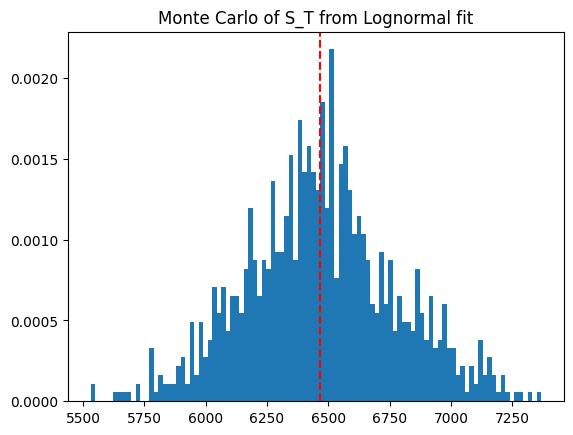

In [13]:
# Inputs (from your RN extraction for a single expiry)
mean_rn = (call_mean_rn[0] + put_mean_rn[0])/2         # E[S_T] from RN PDF
var_rn  = (call_var_rn[0] + put_var_rn[0])       # if you have std, square it; otherwise var_rn directly

today = pd.to_datetime("2025-08-19")
expiry_date = pd.to_datetime(calls_dates[0]) # first expiry date
T =  (expiry_date - today).days / 365.0   # time-to-expiry in years (set accordingly)
S0 = index['Close'].iloc[-1]      # e.g., spx['Close'].iloc[-1]

# 1) compute lognormal parameters m, s2
s2 = np.log(1.0 + var_rn / (mean_rn**2))
m  = np.log(mean_rn) - 0.5*s2
s  = np.sqrt(s2)

# 2) analytic probabilities
# Probability index <= threshold (e.g., crash below 0.9*S0)
threshold = S0
p_below = st.lognorm.cdf(threshold, s, scale=np.exp(m))
p_above = 1 - st.lognorm.cdf(threshold, s, scale=np.exp(m))

print("Lognormal fit params: m =", m, " s =", s)
print(f"P(S_T <= {threshold:.2f}) = {p_below:.4f}")

# 3) simulate paths for S_T (Monte Carlo)
n_sim = 1000
z = np.random.randn(n_sim)
ST_sim = np.exp(m + s*z)   # samples of S_T
# summary
print("Sim mean (sim):", ST_sim.mean(), " quantiles:", np.percentile(ST_sim,[1,5,25,50,75,95,99]))

# 4) plot density
pt.hist(ST_sim, bins=100, density=True)
pt.axvline(threshold, color='r', linestyle='--')
pt.title("Monte Carlo of S_T from Lognormal fit")
pt.show()

P(S_T < thr) = 0.4944
Percentiles: [5647.02381756 5884.23297099 6009.52922597 6226.08388803 6471.86284311
 6735.06330322 6984.37578293 7129.85265005 7442.91051987]


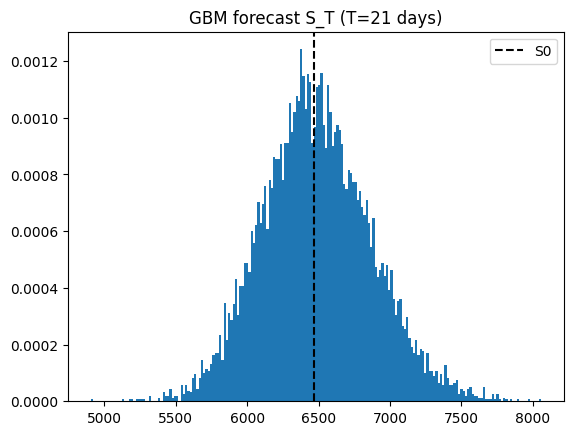

In [14]:
# Inputs
S0 = index['Close'].iloc[-1]  # e.g., spx['Close'].iloc[-1]
risk_free_rate = 0.0492       # e.g., 30-year US bond yield (annualized, continuous compounding)
dividend_yield = 0.017        # e.g., SPX dividend yield (annualized, continuous compounding)

var_rn  = (call_var_rn[0] + put_var_rn[0])       # if you have std, square it; otherwise var_rn directly

sigma_ann = 0.2  # e.g., 0.20 for 20% (use from options)
T_days = 21                      # horizon in trading days
T = T_days / 252.0               # years
# Choose drift:
#   - risk-neutral: mu = r - q  (use if you want RN forecast)
#   - real-world:  mu = historical_drift (or mu_RN + adjustments from your regression)
mu = risk_free_rate - dividend_yield   # risk-neutral drift
# or for real-world:
# mu = annual_real_world_drift  # e.g., 0.07 for 7% p.a.

# simulate many sample paths for S_T
n_sim = 10000
Z = np.random.randn(n_sim)
log_ST = np.log(S0) + (mu - 0.5 * sigma_ann**2) * T + sigma_ann * np.sqrt(T) * Z
ST = np.exp(log_ST)

# compute probabilities & percentiles
p_below = np.mean(ST < threshold)
pctls = np.percentile(ST, [1,5,10,25,50,75,90,95,99])
print("P(S_T < thr) =", p_below)
print("Percentiles:", pctls)

# plot
pt.hist(ST, bins=200, density=True)
pt.axvline(S0, color='k', linestyle='--', label='S0')
pt.title(f"GBM forecast S_T (T={T_days} days)")
pt.legend()
pt.show()

In [15]:
index['simple_return'] = index['Close'].pct_change()
index.tail(30)

,Date,Close,High,Low,Open,Volume,Returns,Rolling_Entropy_KDE,simple_return
1387,2025-07-14,6268.560059,6273.310059,6239.220215,6255.149902,4722250000,0.001407,3.221090,0.001407
1388,2025-07-15,6243.759766,6302.040039,6241.680176,6295.290039,5133670000,-0.003956,3.223797,-0.003956
1389,2025-07-16,6263.700195,6268.120117,6201.589844,6254.500000,5177460000,0.003194,3.299154,0.003194
1390,2025-07-17,6297.359863,6304.689941,6262.270020,6263.399902,5512290000,0.005374,3.398937,0.005374
1391,2025-07-18,6296.790039,6315.609863,6285.270020,6312.950195,5184700000,-0.000090,3.568227,-0.000090
1392,2025-07-21,6305.600098,6336.080078,6303.790039,6304.740234,5010840000,0.001399,3.569739,0.001399
1393,2025-07-22,6309.620117,6316.120117,6281.709961,6306.600098,5662040000,0.000638,3.599918,0.000638
1394,2025-07-23,6358.910156,6360.640137,6317.490234,6326.899902,5642510000,0.007812,3.707579,0.007812
1395,2025-07-24,6363.350098,6381.310059,6360.569824,6368.600098,5282720000,0.000698,3.574336,0.000698
1396,2025-07-25,6388.640137,6395.819824,6368.529785,6370.009766,4470720000,0.003974,3.579210,0.003974


In [16]:
window = 20 #number of trading days
index['rolling_volatility'] =index['Returns'].rolling(window=window).std()
index = index.replace([np.inf, -np.inf], np.nan).dropna()
index


atr_data = index[['Date', 'Close', 'Returns', 'rolling_volatility', 'Rolling_Entropy_KDE']].copy()
atr_data = atr_data.assign(Signal_volatility=0.0, Signal_entropy=0.0)
atr_data

,Date,Close,Returns,rolling_volatility,Rolling_Entropy_KDE,Signal_volatility,Signal_entropy
20,2020-02-03,3248.919922,0.007255,0.007435,3.154196,0.0,0.0
21,2020-02-04,3297.590088,0.014980,0.008112,3.127590,0.0,0.0
22,2020-02-05,3334.689941,0.011251,0.008386,3.178154,0.0,0.0
23,2020-02-06,3345.780029,0.003326,0.008360,3.116183,0.0,0.0
24,2020-02-07,3327.709961,-0.005401,0.008398,3.120028,0.0,0.0
...,...,...,...,...,...,...,...
1412,2025-08-18,6449.149902,-0.000101,0.006650,3.418256,0.0,0.0
1413,2025-08-19,6411.370117,-0.005858,0.006833,3.418273,0.0,0.0
1414,2025-08-20,6395.779785,-0.002432,0.006663,3.379327,0.0,0.0
1415,2025-08-21,6370.169922,-0.004004,0.006731,3.420787,0.0,0.0


In [17]:
datas = atr_data.copy()
# Defining thresholds
# Compute rolling metrics
entropy_threshold_data = datas['Rolling_Entropy_KDE'].rolling(window=10).mean()
vol_threshold_data = datas['rolling_volatility'].rolling(window=10).mean()
rolling_mean_10 = datas['Close'].rolling(window=10).mean()
rolling_max_10 = datas['Close'].rolling(window=10).max()

# Remove first 9 rows (NaN values from rolling)
datas = datas.iloc[9:]  # Copy to avoid modifying the original DataFrame
rolling_mean_10 = rolling_mean_10.iloc[9:]
rolling_max_10 = rolling_max_10.iloc[9:]
entropy_threshold_data = entropy_threshold_data.iloc[9:]
vol_threshold_data = vol_threshold_data.iloc[9:]

# Ensure the signal column exists
if 'Signal_volatility' not in datas.columns:
    print("There is no signal data.")

if 'Signal_entropy' not in datas.columns:
    print("There is no signal data.")

for i in range(datas.shape[0]):  
    # Extract single values (scalars)
    rolling_mean_value = rolling_mean_10.iloc[i].item()  # No .item(), just iloc
    rolling_max_value = rolling_max_10.iloc[i].item()
    vol_threshold = vol_threshold_data.iloc[i].item()
    entropy_threshold = entropy_threshold_data.iloc[i].item()

    # Short signal
    if datas['rolling_volatility'].iloc[i].item() < vol_threshold:
        if datas['Close'].iloc[i].item() < rolling_mean_value:
            datas.iloc[i, datas.columns.get_loc('Signal_volatility')] = -1
    
    # Long signal
    else:
        if datas['Close'].iloc[i].item() >= rolling_max_value:
            datas.iloc[i, datas.columns.get_loc('Signal_volatility')] = 1


    # Short signal for Entropy
    if datas['Rolling_Entropy_KDE'].iloc[i].item() < entropy_threshold:
        if datas['Close'].iloc[i].item() < rolling_mean_value:
            datas.iloc[i, datas.columns.get_loc('Signal_entropy')] = -1
    
    # Long signal for Entropy
    else:
        if datas['Close'].iloc[i].item() >= rolling_max_value:
            datas.iloc[i, datas.columns.get_loc('Signal_entropy')] = 1



atr_signal = datas.copy()

atr_signal

,Date,Close,Returns,rolling_volatility,Rolling_Entropy_KDE,Signal_volatility,Signal_entropy
29,2020-02-14,3380.159912,0.001844,0.008293,3.100361,1.0,0.0
30,2020-02-18,3370.290039,-0.002920,0.008308,3.132254,0.0,0.0
31,2020-02-19,3386.149902,0.004706,0.008317,3.122736,0.0,1.0
32,2020-02-20,3373.229980,-0.003816,0.008386,3.127966,0.0,0.0
33,2020-02-21,3337.750000,-0.010518,0.008758,3.111391,0.0,-1.0
...,...,...,...,...,...,...,...
1412,2025-08-18,6449.149902,-0.000101,0.006650,3.418256,0.0,0.0
1413,2025-08-19,6411.370117,-0.005858,0.006833,3.418273,0.0,-1.0
1414,2025-08-20,6395.779785,-0.002432,0.006663,3.379327,0.0,-1.0
1415,2025-08-21,6370.169922,-0.004004,0.006731,3.420787,0.0,-1.0


In [18]:
print(atr_signal['Signal_volatility'].value_counts())
print(atr_signal['Signal_entropy'].value_counts())

Signal_volatility
 0.0    1076
-1.0     183
 1.0     129
Name: count, dtype: int64
Signal_entropy
 0.0    858
-1.0    309
 1.0    221
Name: count, dtype: int64


Long position open at 3380.159912109375
Long position closed at 3370.2900390625
Short position open at 2736.56005859375
Short position closed at 2799.31005859375
Short position open at 2797.800048828125
Short position closed at 2836.739990234375
Short position open at 2830.7099609375
Short position closed at 2842.739990234375
Short position open at 2842.739990234375
Short position closed at 2868.43994140625
Short position open at 2848.419921875
Short position closed at 2881.18994140625
Short position open at 2870.1201171875
Short position closed at 2820.0
Short position open at 2820.0
Short position closed at 2852.5
Short position open at 2852.5
Short position closed at 2863.699951171875
Short position open at 2863.699951171875
Short position closed at 2953.909912109375
Long position open at 3179.719970703125
Long position closed at 3145.320068359375
Short position open at 3215.6298828125
Short position closed at 3239.409912109375
Short position open at 3218.43994140625
Short position 

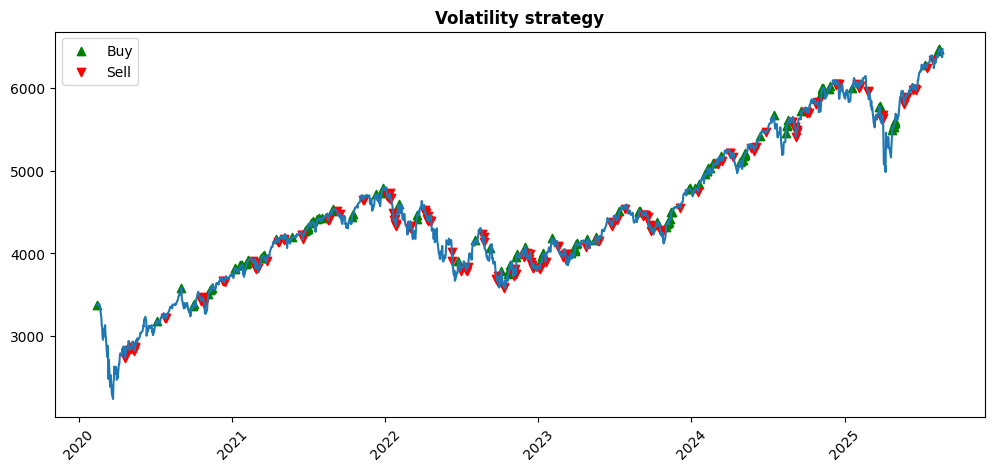

In [19]:
def backtest_strategy_alt(data: pd.DataFrame):
    # Ensure index is in datetime format
    data.index = pd.to_datetime(data['Date'])

    position = False
    percent_change = []

    for i in data.index:
        if i not in data.index:
            print(f"Skipping missing date: {i}")
            continue  # Skip missing dates

        price = data.loc[i, "Close"].item()
        date = i
        i_pos = data.index.get_loc(i)  # Get integer position of i

        # Long position
        if (data.loc[i, "Signal_volatility"].item() == 1) and (not position):
            buy_price = price
            position = True
            data.at[i, 'buy_date'] = date
            print(f"Long position open at {buy_price}")

            #close position after 5% profit or 0.5% loss or close immediately after a span of 45 days from the position opening
            for k in range(i_pos + 1, min(i_pos + 46, len(data))):
                market_price = data["Close"].iloc[k].item()
                percent = (market_price/price) - 1
                if (percent >= 0.05) and position:
                    percent_change.append(percent)
                    position = False
                    print(f"Long position closed at {market_price}")
                    break
            
                if (percent <= -0.005) and position:
                    percent_change.append(percent)
                    position = False
                    print(f"Long position closed at {market_price}")
                    break

                else:
                    percent_change.append(percent)
                    position = False
                    print(f"Long position closed at {market_price}")
                    break


        # Short position
        if (data.loc[i, "Signal_volatility"].item() == -1) and (not position):
            sell_price = price
            position = True
            data.at[i, 'sell_date'] = date
            print(f"Short position open at {sell_price}")

            #close position after 5% profit or 1% loss or close immediately after a span of 45 days from the position opening
            for k in range(i_pos + 1, min(i_pos + 46, len(data))):
                market_price = data["Close"].iloc[k].item()
                percent = (market_price/price) - 1
                if (percent >= 0.05) and position:
                    percent_change.append(percent)
                    position = False
                    print(f"Short position closed at {market_price}")
                    break
            
                if (percent <= -0.005) and position:
                    percent_change.append(percent)
                    position = False
                    print(f"Short position closed at {market_price}")
                    break

                else:
                    percent_change.append(percent)
                    position = False
                    print(f"Short position closed at {market_price}")
                    break

    trades_count = len(percent_change)
    won_trades = sum(1 for x in percent_change if x > 0)
    lost_trades = sum(1 for x in percent_change if x < 0)

    # Recursively calculate return
    def calculate_return(total_return, per_change, i):
        if i == len(per_change):
            return total_return
        return calculate_return(total_return * (per_change[i] + 1), per_change, i + 1)

    total_return = round((calculate_return(1, percent_change, 0) - 1) * 100, 5)

    print("\n--------------------------------")
    print(f"Number of Trades: {trades_count}")
    print(f"Wins: {won_trades}")
    print(f"Losses: {lost_trades}")
    print(f"Total Returns: {total_return}%\n")

    return percent_change


# Run backtest with atr_signal DataFrame
percent_volaility = backtest_strategy_alt(atr_signal)

signal_df = atr_signal.copy()
pt.figure(figsize=(12,5))
pt.xticks(rotation=45)

pt.plot(signal_df.index, signal_df['Close'])
pt.scatter(signal_df[signal_df['Signal_volatility'] == 1].index, signal_df[signal_df['Signal_volatility'] == 1]['Close'], label='Buy', marker='^', c='g')
pt.scatter(signal_df[signal_df['Signal_volatility'] == -1].index, signal_df[signal_df['Signal_volatility'] == -1]['Close'], label='Sell', marker='v', c='r')

pt.title('Volatility strategy', fontweight="bold")
pt.legend()
pt.show()

Long position open at 3386.14990234375
Long position closed at 3373.22998046875
Short position open at 3337.75
Short position closed at 3225.889892578125
Short position open at 3225.889892578125
Short position closed at 3128.2099609375
Short position open at 3128.2099609375
Short position closed at 3116.389892578125
Short position open at 3116.389892578125
Short position closed at 2978.760009765625
Short position open at 2978.760009765625
Short position closed at 2954.219970703125
Short position open at 2954.219970703125
Short position closed at 3090.22998046875
Short position open at 3090.22998046875
Short position closed at 3003.3701171875
Short position open at 3003.3701171875
Short position closed at 3130.1201171875
Short position open at 3130.1201171875
Short position closed at 3023.93994140625
Short position open at 3023.93994140625
Short position closed at 2972.3701171875
Short position open at 2972.3701171875
Short position closed at 2746.56005859375
Short position open at 2746

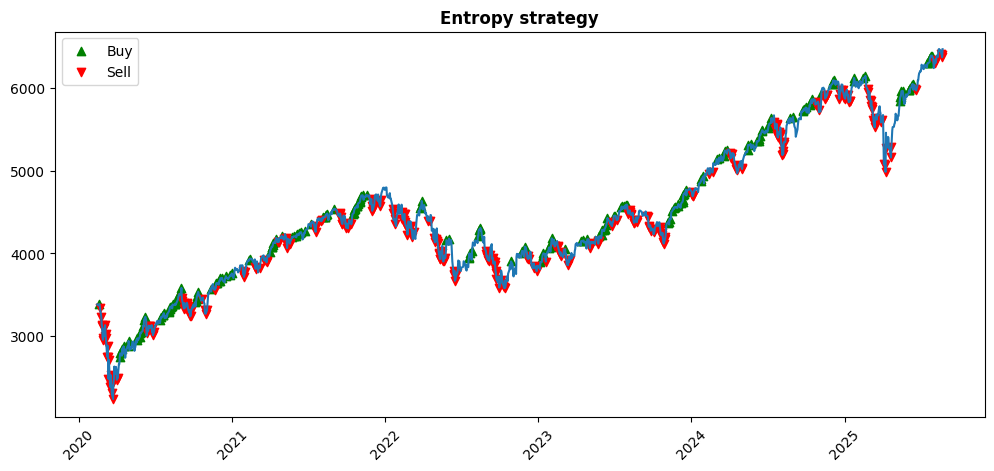

In [20]:
def backtest_strategy_alt(data: pd.DataFrame):
    # Ensure index is in datetime format
    data.index = pd.to_datetime(data['Date'])

    position = False
    percent_change = []

    for i in data.index:
        if i not in data.index:
            print(f"Skipping missing date: {i}")
            continue  # Skip missing dates

        price = data.loc[i, "Close"].item()
        date = i
        i_pos = data.index.get_loc(i)  # Get integer position of i

        # Long position
        if (data.loc[i, "Signal_entropy"].item() == 1) and (not position):
            buy_price = price
            position = True
            data.at[i, 'buy_date'] = date
            print(f"Long position open at {buy_price}")

            #close position after 5% profit or 0.5% loss or close immediately after a span of 45 days from the position opening
            for k in range(i_pos + 1, min(i_pos + 46, len(data))):
                market_price = data["Close"].iloc[k].item()
                percent = (market_price/price) - 1
                if (percent >= 0.05) and position:
                    percent_change.append(percent)
                    position = False
                    print(f"Long position closed at {market_price}")
                    break
            
                if (percent <= -0.005) and position:
                    percent_change.append(percent)
                    position = False
                    print(f"Long position closed at {market_price}")
                    break

                else:
                    percent_change.append(percent)
                    position = False
                    print(f"Long position closed at {market_price}")
                    break


        # Short position
        if (data.loc[i, "Signal_entropy"].item() == -1) and (not position):
            sell_price = price
            position = True
            data.at[i, 'sell_date'] = date
            print(f"Short position open at {sell_price}")

            #close position after 5% profit or 1% loss or close immediately after a span of 45 days from the position opening
            for k in range(i_pos + 1, min(i_pos + 46, len(data))):
                market_price = data["Close"].iloc[k].item()
                percent = (market_price/price) - 1
                if (percent >= 0.05) and position:
                    percent_change.append(percent)
                    position = False
                    print(f"Short position closed at {market_price}")
                    break
            
                if (percent <= -0.005) and position:
                    percent_change.append(percent)
                    position = False
                    print(f"Short position closed at {market_price}")
                    break

                else:
                    percent_change.append(percent)
                    position = False
                    print(f"Short position closed at {market_price}")
                    break

    trades_count = len(percent_change)
    won_trades = sum(1 for x in percent_change if x > 0)
    lost_trades = sum(1 for x in percent_change if x < 0)

    # Recursively calculate return
    def calculate_return(total_return, per_change, i):
        if i == len(per_change):
            return total_return
        return calculate_return(total_return * (per_change[i] + 1), per_change, i + 1)

    total_return = round((calculate_return(1, percent_change, 0) - 1) * 100, 5)

    print("\n--------------------------------")
    print(f"Number of Trades: {trades_count}")
    print(f"Wins: {won_trades}")
    print(f"Losses: {lost_trades}")
    print(f"Total Returns: {total_return}%\n")

    return percent_change

# Run backtest with atr_signal DataFrame
percent_entropy = backtest_strategy_alt(atr_signal)

signal_df = atr_signal.copy()
pt.figure(figsize=(12,5))
pt.xticks(rotation=45)

pt.plot(signal_df.index, signal_df['Close'])
pt.scatter(signal_df[signal_df['Signal_entropy'] == 1].index, signal_df[signal_df['Signal_entropy'] == 1]['Close'], label='Buy', marker='^', c='g')
pt.scatter(signal_df[signal_df['Signal_entropy'] == -1].index, signal_df[signal_df['Signal_entropy'] == -1]['Close'], label='Sell', marker='v', c='r')

pt.title('Entropy strategy', fontweight="bold")
pt.legend()
pt.show()

In [21]:
def sharpe_ratio(returns, risk_free_rate, periods_per_year=252):
    """
    Calculate annualized Sharpe ratio.
    
    Parameters:
    - returns: pd.Series of periodic returns (e.g. daily % returns as decimals, not prices)
    - risk_free_rate: annual risk-free rate in decimals (e.g. 0.02 for 2%)
    - periods_per_year: 252 (daily), 52 (weekly), 12 (monthly)
    """
    
    # Convert annual risk-free rate to per-period
    rf_per_period = (1 + risk_free_rate) ** (1/periods_per_year) - 1
    
    # Excess returns
    excess_returns = returns - rf_per_period
    
    # Mean and std deviation of excess returns
    mean_excess = excess_returns.mean()
    std_excess = excess_returns.std()
    
    # Sharpe ratio (annualized)
    sharpe = (mean_excess / std_excess) * np.sqrt(periods_per_year)
    return sharpe


# Convert column to pandas Series
returns_volatility = pd.Series(percent_volaility)
returns_entropy = pd.Series(percent_entropy)

# Calculate Sharpe ratio (daily returns, 4.5% risk-free annual rate)
# Risk free rate: 30 year US Bond yield
sharpe_volatility = sharpe_ratio(returns_volatility, risk_free_rate=0.045, periods_per_year=252)
sharpe_entropy = sharpe_ratio(returns_entropy, risk_free_rate=0.045, periods_per_year=252)

print("Volatility Strategy Sharpe Ratio:", sharpe_volatility)
print("Entropy Strategy Sharpe Ratio:", sharpe_entropy)

Volatility Strategy Sharpe Ratio: 0.47798937094629207
Entropy Strategy Sharpe Ratio: 0.4436512400070199
